# Practica - Unidad 3: Procesamiento del Lenguaje

**Materia:** Procesamiento de Lenguaje Natural
**Carrera:** TUIA - Universidad Nacional de Rosario

---

Esta practica abarca las tecnicas fundamentales de procesamiento del lenguaje natural presentadas en la Unidad 3. A lo largo del notebook trabajaremos con seis grandes temas:

1. **Extraccion de frases sustantivas** (Noun Phrase Extraction)
2. **Semejanza de texto** (Text Similarity)
3. **POS Tagging y NER** (Parts of Speech / Named Entity Recognition)
4. **Clasificacion de texto** (Text Classification)
5. **Analisis de sentimientos** (Sentiment Analysis)
6. **Busqueda semantica** (Semantic Search)

Cada seccion contiene:
- Una explicacion teorica concisa del tema.
- Ejemplos practicos ejecutables con datos realistas.
- Ejercicios para resolver.

**Nota:** Algunos modelos (especialmente los basados en Transformers) pueden demorar en descargarse la primera vez. Es esperable.

---

### Instalacion de dependencias

Ejecuta la siguiente celda para instalar todas las librerias necesarias.

In [ ]:
#!pip install spacy scikit-learn python-Levenshtein thefuzz jellyfish nltk transformers sentence-transformers sentiment-analysis-spanish torch numpy pandas matplotlib seaborn stanza gliner
#!python -m spacy download es_core_news_lg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.0/30.0 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 35.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 1.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reloa

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

---

## 1. Extraccion de frases sustantivas (Noun Phrase Extraction)

### Fundamento teorico

En NLP, la **extraccion de frases sustantivas** (Noun Phrase Extraction) consiste en identificar y extraer las frases que funcionan como sustantivos dentro de un texto.

Una **frase sustantiva** (tambien llamada sintagma nominal) es una estructura gramatical cuyo nucleo es un sustantivo. Su funcion principal es nombrar o identificar personas, lugares, cosas, ideas o eventos. Puede actuar como sujeto, objeto directo, objeto indirecto, complemento de preposicion, entre otros roles dentro de una oracion.

#### Estructura de una frase sustantiva

Una frase sustantiva puede estar compuesta por:

1. **Nucleo:** El sustantivo principal (obligatorio).
2. **Determinante:** Articulos, posesivos, demostrativos que acompanan al sustantivo (ej. "el", "una", "mi").
3. **Modificadores:** Adjetivos o frases adjetivas que describen al sustantivo (ej. "grande", "veloz").
4. **Complementos:** Palabras o frases que completan el sentido del sustantivo (ej. "de Juan").

#### Ejemplos

| Frase sustantiva | Determinante | Nucleo | Modificador/Complemento |
|---|---|---|---|
| El perro grande | El | perro | grande |
| La casa de Juan | La | casa | de Juan |
| Un libro interesante | Un | libro | interesante |
| Los estudiantes universitarios | Los | estudiantes | universitarios |
| Mi nuevo proyecto de investigacion | Mi | proyecto | nuevo, de investigacion |

#### Aplicaciones

- **Extraccion de informacion:** identificar de que se habla en un texto.
- **Indexacion de documentos:** determinar los temas principales de un corpus.
- **Construccion de grafos de conocimiento:** identificar entidades y relaciones.
- **Resumen automatico:** seleccionar las frases clave de un texto largo.
- **Analisis de tendencias:** detectar temas emergentes en noticias o redes sociales.

En Python, la libreria `spaCy` permite extraer frases sustantivas directamente mediante la propiedad `doc.noun_chunks`. Cada chunk tiene atributos como `text` (el texto completo), `root` (el nucleo), `root.pos_` (la etiqueta POS del nucleo) y `root.dep_` (la relacion de dependencia).

### Ejemplo practico: Extraccion basica con spaCy

Comenzaremos con un texto periodistico breve para ver como spaCy identifica las frases sustantivas automaticamente.

In [ ]:
import spacy

# Cargamos el modelo de espanol (grande, con vectores)
nlp = spacy.load('es_core_news_lg')

texto = """El Banco Central de la Republica Argentina anuncio una nueva
politica monetaria para controlar la inflacion interanual.
Los analistas del mercado financiero anticipan efectos positivos
en el tipo de cambio oficial durante los proximos meses."""

doc = nlp(texto)

print("Texto original:")
print(texto)
print("\nFrases sustantivas encontradas:")
print("-" * 60)

for chunk in doc.noun_chunks:
    print(f"  Frase: '{chunk.text}'")
    print(f"    Nucleo (root): '{chunk.root.text}'")
    print(f"    Etiqueta del nucleo: {chunk.root.pos_} ({spacy.explain(chunk.root.pos_)})")
    print(f"    Dependencia: {chunk.root.dep_} ({spacy.explain(chunk.root.dep_)})")
    print()

Texto original:
El Banco Central de la Republica Argentina anuncio una nueva
politica monetaria para controlar la inflacion interanual.
Los analistas del mercado financiero anticipan efectos positivos
en el tipo de cambio oficial durante los proximos meses.

Frases sustantivas encontradas:
------------------------------------------------------------
  Frase: 'El Banco Central de la Republica Argentina'
    Nucleo (root): 'Banco'
    Etiqueta del nucleo: PROPN (proper noun)
    Dependencia: nsubj (nominal subject)

  Frase: 'la inflacion interanual'
    Nucleo (root): 'inflacion'
    Etiqueta del nucleo: NOUN (noun)
    Dependencia: obj (object)

  Frase: 'Los analistas'
    Nucleo (root): 'analistas'
    Etiqueta del nucleo: NOUN (noun)
    Dependencia: nsubj (nominal subject)

  Frase: 'mercado financiero'
    Nucleo (root): 'mercado'
    Etiqueta del nucleo: NOUN (noun)
    Dependencia: nmod (modifier of nominal)

  Frase: 'efectos positivos
'
    Nucleo (root): 'efectos'
    Etiquet

Observa que spaCy identifica frases sustantivas completas, incluyendo determinantes, adjetivos y complementos preposicionales. El nucleo (`root`) siempre es un sustantivo, y la relacion de dependencia (`dep_`) nos dice que funcion cumple esa frase en la oracion (sujeto, objeto, etc.).

### Ejemplo practico: Analisis de frases sustantivas en un articulo de noticias

Veamos un caso mas realista: analizar un fragmento de un articulo periodistico completo para identificar los temas principales a traves de sus frases sustantivas.

In [ ]:
import pandas as pd
from collections import Counter

articulo = """La empresa argentina de tecnologia Globant reporto ingresos por 587 millones
de dolares durante el tercer trimestre de 2024, lo que representa un crecimiento del 12%
respecto al mismo periodo del ano anterior. El director ejecutivo, Martin Migoya,
destaco la expansion en mercados europeos y la creciente demanda de servicios
de inteligencia artificial por parte de grandes corporaciones multinacionales.

La compania, que cotiza en la Bolsa de Nueva York bajo el ticker GLOB, emplea
actualmente a mas de 29.000 profesionales distribuidos en 25 paises. Los sectores
de mayor crecimiento fueron los servicios financieros, la industria automotriz
y el comercio electronico. Los analistas de Wall Street proyectan que la accion
alcanzara los 250 dolares para fin de ano."""

doc = nlp(articulo)

# Extraemos frases sustantivas con informacion detallada
data = []
for chunk in doc.noun_chunks:
    data.append({
        'Frase': chunk.text,
        'Nucleo': chunk.root.text,
        'POS Nucleo': chunk.root.pos_,
        'Dependencia': chunk.root.dep_,
        'Num. Palabras': len(chunk.text.split())
    })

df_chunks = pd.DataFrame(data)
print(f"Total de frases sustantivas encontradas: {len(df_chunks)}")
print(f"Promedio de palabras por frase: {df_chunks['Num. Palabras'].mean():.1f}")
print(f"Frase mas larga: '{df_chunks.loc[df_chunks['Num. Palabras'].idxmax(), 'Frase']}'")
print(f"\nTodas las frases sustantivas:")
print(df_chunks.to_string(index=False))

Total de frases sustantivas encontradas: 36
Promedio de palabras por frase: 2.3
Frase mas larga: 'mas de 29.000 profesionales distribuidos en 25 paises'

Todas las frases sustantivas:
                                                Frase        Nucleo POS Nucleo Dependencia  Num. Palabras
                                 La empresa argentina       empresa       NOUN       nsubj              3
                                           tecnologia    tecnologia       NOUN        nmod              1
                                              Globant       Globant      PROPN       appos              1
                                             ingresos      ingresos       NOUN         obj              1
                                         587 millones      millones       NOUN        nmod              2
                                              dolares       dolares       NOUN        nmod              1
                                  el tercer trimestre     trimestre       

### Ejemplo practico: Frecuencia de nucleos sustantivos

Una tecnica util para entender de que trata un texto es contar la frecuencia de los nucleos de las frases sustantivas. Esto nos da una idea de los temas centrales del documento.

In [ ]:
# Contamos frecuencia de nucleos sustantivos (lematizados)
nucleos = [chunk.root.lemma_.lower() for chunk in doc.noun_chunks]
frecuencias = Counter(nucleos)

print("Top 10 nucleos sustantivos mas frecuentes:")
print("-" * 40)
for nucleo, freq in frecuencias.most_common(10):
    barra = '#' * (freq * 5)
    print(f"  {nucleo:<20} {freq:>2} {barra}")

Top 10 nucleos sustantivos mas frecuentes:
----------------------------------------
  dolar                 2 ##########
  que                   2 ##########
  crecimiento           2 ##########
  ano                   2 ##########
  empresa               1 #####
  tecnologia            1 #####
  globant               1 #####
  ingreso               1 #####
  millón                1 #####
  trimestre             1 #####


### Ejercicio 1.1: Extraccion basica de frases sustantivas

Dado el siguiente texto sobre cambio climatico:

```
"Las temperaturas globales han aumentado significativamente en las ultimas decadas.
Los cientificos del panel intergubernamental advierten sobre las graves consecuencias
del calentamiento global. Las energias renovables representan una solucion viable
para reducir las emisiones de gases de efecto invernadero. La transicion energetica
requiere inversiones millonarias y un compromiso firme de los gobiernos nacionales."
```

1. Procesa el texto con spaCy y extrae todas las frases sustantivas.
2. Para cada frase, imprime: el texto completo, el nucleo, y la cantidad de palabras que la componen.
3. Identifica cual es la frase sustantiva mas larga (en cantidad de palabras).
4. Lista los nucleos unicos (sin repetir) y cuenta cuantos hay.

In [ ]:
articulo = """Las temperaturas globales han aumentado significativamente en las ultimas decadas.
Los cientificos del panel intergubernamental advierten sobre las graves consecuencias
del calentamiento global. Las energias renovables representan una solucion viable
para reducir las emisiones de gases de efecto invernadero. La transicion energetica
requiere inversiones millonarias y un compromiso firme de los gobiernos nacionales."""

def extraer_frases_sustantivas(documento):
  doc = nlp(documento)

  # Extraemos frases sustantivas con informacion detallada
  data = []
  for chunk in doc.noun_chunks:
      data.append({
          'Frase': chunk.text,
          'Nucleo': chunk.root.text,
          'POS Nucleo': chunk.root.pos_,
          'Dependencia': chunk.root.dep_,
          'Num. Palabras': len(chunk.text.split())
      })

  df_chunks = pd.DataFrame(data)
  print(f"Total de frases sustantivas encontradas: {len(df_chunks)}")
  print(f"Promedio de palabras por frase: {df_chunks['Num. Palabras'].mean():.1f}")
  print(f"Frase mas larga: '{df_chunks.loc[df_chunks['Num. Palabras'].idxmax(), 'Frase']}'")
  print(f"\nTodas las frases sustantivas:")
  print(df_chunks.to_string(index=False))

  nucleos = [chunk.root.lemma_.lower() for chunk in doc.noun_chunks]
  frecuencias = Counter(nucleos)

  print("Top 10 nucleos sustantivos mas frecuentes:")
  print("-" * 40)
  for nucleo, freq in frecuencias.most_common(10):
      barra = '#' * (freq * 5)
      print(f"  {nucleo:<20} {freq:>2} {barra}")

extraer_frases_sustantivas(articulo)

Total de frases sustantivas encontradas: 16
Promedio de palabras por frase: 2.2
Frase mas larga: 'Las temperaturas globales'

Todas las frases sustantivas:
                     Frase        Nucleo POS Nucleo Dependencia  Num. Palabras
 Las temperaturas globales  temperaturas       NOUN       nsubj              3
       las ultimas decadas       decadas       NOUN         obl              3
           Los cientificos   cientificos       NOUN       nsubj              2
  panel intergubernamental         panel       NOUN        nmod              2
  las graves consecuencias consecuencias       NOUN         obl              3
      calentamiento global calentamiento       NOUN        nmod              2
   Las energias renovables      energias       NOUN       nsubj              3
     una solucion viable\n      solucion       NOUN         obj              3
             las emisiones     emisiones       NOUN         obj              2
                     gases         gases       NOUN   

### Ejercicio 1.2: Analisis comparativo de frases sustantivas por estilo

Toma los siguientes dos textos con estilos muy distintos (uno periodistico y otro literario) y compara las frases sustantivas extraidas:

**Texto periodistico:**
```
"El presidente de la Nacion anuncio nuevas medidas economicas durante la conferencia
de prensa celebrada en la Casa Rosada. El ministro de Economia presento el plan
de estabilizacion macroeconomica ante el Congreso de la Nacion y los representantes
del sector empresarial."
```

**Texto literario:**
```
"La vieja casona de piedra dormia bajo un manto de niebla espesa y silenciosa.
Los arboles centenarios del jardin abandonado susurraban secretos indescifrables
al viento frio de la madrugada. Una sombra fugaz cruzo el porton oxidado del fondo."
```

1. Extrae las frases sustantivas de ambos textos.
2. Calcula la cantidad promedio de palabras por frase sustantiva en cada texto.
3. Compara la distribucion de las dependencias sintacticas (nsubj, obj, obl, etc.) en cada texto.
4. Reflexiona (en un comentario de Python): cual texto tiene frases sustantivas mas descriptivas y por que.

In [ ]:
texto_periodistico = """El presidente de la Nacion anunció nuevas medidas economicas durante la conferencia
de prensa celebrada en la Casa Rosada. El ministro de Economia presento el plan
de estabilizacion macroeconomica ante el Congreso de la Nacion y los representantes del sector empresarial."""

texto_litarario = """La vieja casona de piedra dormia bajo un manto de niebla espesa y silenciosa.
Los arboles centenarios del jardin abandonado susurraban secretos indescifrables al viento frio de la madrugada. Una sombra fugaz cruzo el porton oxidado del fondo."""

In [ ]:
extraer_frases_sustantivas(texto_periodistico)

Total de frases sustantivas encontradas: 11
Promedio de palabras por frase: 2.7
Frase mas larga: 'el Congreso de la Nacion y los representantes del sector empresarial'

Todas las frases sustantivas:
                                                               Frase         Nucleo POS Nucleo Dependencia  Num. Palabras
                                                       El presidente     presidente       NOUN       nsubj              2
                                                           la Nacion         Nacion      PROPN        nmod              2
                                           nuevas medidas economicas        medidas       NOUN         obj              3
                                                      la conferencia    conferencia       NOUN         obl              2
                                                              prensa         prensa       NOUN        nmod              1
                                                      la Casa Rosada 

In [ ]:
extraer_frases_sustantivas(texto_litarario)

Total de frases sustantivas encontradas: 12
Promedio de palabras por frase: 2.3
Frase mas larga: 'niebla espesa y silenciosa'

Todas las frases sustantivas:
                     Frase    Nucleo POS Nucleo Dependencia  Num. Palabras
           La vieja casona    casona       NOUN       nsubj              3
                    piedra    piedra       NOUN        nmod              1
                  un manto     manto       NOUN         obl              2
niebla espesa y silenciosa    niebla       NOUN        nmod              4
   Los arboles centenarios   arboles       NOUN       nsubj              3
         jardin abandonado    jardin      PROPN        nmod              2
   secretos indescifrables  secretos       NOUN         obj              2
               viento frio    viento       NOUN         obl              2
              la madrugada madrugada       NOUN        nmod              2
          Una sombra fugaz    sombra       NOUN       nsubj              3
         el porton

3. Compara la distribucion de las dependencias sintacticas (nsubj, obj, obl, etc.) en cada texto.

???

4. Reflexiona (en un comentario de Python): cual texto tiene frases sustantivas mas descriptivas y por que.

El texto literario tiene frases mas descriptivas, ya que usa mas adjetivos.

### Ejercicio 1.3: Extraccion de temas desde un aviso laboral

Dado el siguiente aviso de trabajo real:

```python
aviso = """Buscamos un Ingeniero de Datos Senior para nuestro equipo de Analytics
en la oficina de Buenos Aires. El candidato ideal debe tener experiencia solida
en pipelines de datos con Apache Spark y Apache Airflow. Se requiere conocimiento
avanzado de bases de datos relacionales como PostgreSQL y bases de datos NoSQL
como MongoDB. Ofrecemos un salario competitivo en dolares, cobertura medica premium
para el grupo familiar, y la posibilidad de trabajo remoto tres dias por semana.
La empresa es una fintech en rapido crecimiento con mas de 200 empleados
en America Latina."""
```

1. Extrae todas las frases sustantivas del aviso.
2. Clasifica manualmente (o con logica simple) las frases sustantivas en tres grupos: **requisitos tecnicos**, **beneficios** y **informacion de la empresa**.
3. Genera un resumen automatico listando los nucleos sustantivos mas importantes.

*Pista:* Puedes usar las dependencias sintacticas y buscar patrones para la clasificacion.

In [ ]:
aviso = """Buscamos un Ingeniero de Datos Senior para nuestro equipo de Analytics en la oficina de Buenos Aires. El candidato ideal debe tener experiencia solida en pipelines de datos con Apache Spark y Apache Airflow. Se requiere conocimiento
avanzado de bases de datos relacionales como PostgreSQL y bases de datos NoSQL como MongoDB. Ofrecemos un salario competitivo en dolares, cobertura medica premium
para el grupo familiar, y la posibilidad de trabajo remoto tres dias por semana. La empresa es una fintech en rapido crecimiento con mas de 200 empleados en America Latina."""

extraer_frases_sustantivas(aviso)

Total de frases sustantivas encontradas: 30
Promedio de palabras por frase: 2.0
Frase mas larga: 'Apache Spark y Apache Airflow'

Todas las frases sustantivas:
                        Frase       Nucleo POS Nucleo Dependencia  Num. Palabras
                 un Ingeniero    Ingeniero      PROPN       nsubj              2
                 Datos Senior        Datos      PROPN        nmod              2
               nuestro equipo       equipo       NOUN         obl              2
                    Analytics    Analytics      PROPN        nmod              1
                   la oficina      oficina       NOUN         obl              2
                 Buenos Aires       Buenos      PROPN        nmod              2
           El candidato ideal    candidato       NOUN       nsubj              3
           experiencia solida  experiencia       NOUN         obj              2
                    pipelines    pipelines       NOUN        nmod              1
                        datos 

---

## 2. Semejanza de texto (Text Similarity)

### Fundamento teorico

La **semejanza de texto** es un area del NLP que se centra en determinar el grado de similitud o equivalencia entre dos fragmentos de texto. Es fundamental para aplicaciones como:

- **Sistemas de recomendacion:** recomendar contenido similar al que el usuario consumio.
- **Deteccion de plagio:** identificar copias textuales o parafraseos en trabajos academicos.
- **Respuesta automatica a preguntas (QA):** encontrar la respuesta mas relevante.
- **Deduplicacion de datos:** detectar registros duplicados en bases de datos.
- **Agrupamiento de textos:** crear clusters de documentos similares.

Existen diversas metricas para medir semejanza, cada una con sus ventajas y limitaciones:

| Metrica | Que mide | Rango | Mejor para |
|---|---|---|---|
| Similitud del coseno | Angulo entre vectores | [-1, 1] | Textos vectorizados (TF-IDF, embeddings) |
| Distancia de Jaccard | Solapamiento de conjuntos | [0, 1] | Comparacion a nivel de palabras (tokens) |
| Similitud de Dice | Solapamiento ponderado de conjuntos | [0, 1] | Similar a Jaccard, mas sensible a coincidencias |
| Distancia de Levenshtein | Operaciones de edicion minimas | [0, inf) | Cadenas cortas, correccion ortografica |
| Similitud de Jaro-Winkler | Caracteres comunes y transposiciones | [0, 1] | Nombres propios, cadenas cortas |

La eleccion de la metrica depende del tipo de texto, la granularidad deseada (caracter, palabra, documento) y el problema especifico a resolver.

### Ejemplo practico: Similitud del coseno con TF-IDF

La **similitud del coseno** mide el angulo entre dos vectores en un espacio vectorial. Si dos documentos tratan temas similares, sus vectores TF-IDF apuntaran en direcciones parecidas, dando una similitud cercana a 1.

Veamos un ejemplo con fragmentos de noticias reales sobre diferentes temas.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Corpus de fragmentos de noticias sobre diferentes temas
noticias = [
    "El Banco Central elevo la tasa de interes de referencia al 97% anual para contener la inflacion que acumula un 142% interanual.",
    "La autoridad monetaria decidio incrementar el rendimiento de las Leliq para frenar la escalada de precios en la economia argentina.",
    "River Plate vencio 3-1 a Boca Juniors en el Superclasico disputado en el estadio Monumental ante 72.000 espectadores.",
    "El equipo millonario se impuso con goles de Borja, Solari y Barco en el clasico del futbol argentino.",
    "La NASA confirmo el lanzamiento exitoso del telescopio espacial James Webb desde la base de Kourou en la Guayana Francesa.",
    "SpaceX lanzo con exito 23 satelites Starlink a bordo de un cohete Falcon 9 desde Cabo Canaveral, Florida.",
    "El precio del barril de petroleo Brent subio un 3.5% y cerro en 87 dolares tras las tensiones en Medio Oriente.",
]

# Vectorizamos con TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(noticias)

print(f"Dimensiones de la matriz TF-IDF: {tfidf_matrix.shape}")
print(f"  -> {tfidf_matrix.shape[0]} documentos, {tfidf_matrix.shape[1]} terminos unicos\n")

# Calculamos la matriz completa de similitud del coseno
sim_matrix = cosine_similarity(tfidf_matrix)

# Mostramos como DataFrame para mejor lectura
etiquetas = [f"N{i}" for i in range(len(noticias))]
df_sim = pd.DataFrame(sim_matrix, index=etiquetas, columns=etiquetas)
print("Matriz de similitud del coseno:")
print(df_sim.round(3).to_string())

# Encontramos los pares mas similares (excluyendo la diagonal)
print("\nTop 3 pares mas similares:")
print("-" * 60)
pares = []
for i in range(len(noticias)):
    for j in range(i+1, len(noticias)):
        pares.append((i, j, sim_matrix[i][j]))
pares.sort(key=lambda x: x[2], reverse=True)

for i, j, sim in pares[:3]:
    print(f"  N{i} vs N{j} (similitud: {sim:.4f})")
    print(f"    N{i}: '{noticias[i][:80]}...'")
    print(f"    N{j}: '{noticias[j][:80]}...'")
    print()

Dimensiones de la matriz TF-IDF: (7, 96)
  -> 7 documentos, 96 terminos unicos

Matriz de similitud del coseno:
       N0     N1     N2     N3     N4     N5     N6
N0  1.000  0.257  0.026  0.056  0.196  0.058  0.069
N1  0.257  1.000  0.062  0.076  0.299  0.028  0.116
N2  0.026  0.062  1.000  0.104  0.062  0.000  0.106
N3  0.056  0.076  0.104  1.000  0.093  0.066  0.122
N4  0.196  0.299  0.062  0.093  1.000  0.057  0.091
N5  0.058  0.028  0.000  0.066  0.057  1.000  0.050
N6  0.069  0.116  0.106  0.122  0.091  0.050  1.000

Top 3 pares mas similares:
------------------------------------------------------------
  N1 vs N4 (similitud: 0.2989)
    N1: 'La autoridad monetaria decidio incrementar el rendimiento de las Leliq para fren...'
    N4: 'La NASA confirmo el lanzamiento exitoso del telescopio espacial James Webb desde...'

  N0 vs N1 (similitud: 0.2570)
    N0: 'El Banco Central elevo la tasa de interes de referencia al 97% anual para conten...'
    N1: 'La autoridad monetaria decidi

Observa como las noticias del mismo tema (economia, deportes, espacio) tienen mayor similitud entre si, incluso cuando usan palabras diferentes. Esto se debe a que comparten vocabulario tematico que TF-IDF captura.

### Ejemplo practico: Distancia de Jaccard (implementacion manual)

La **distancia de Jaccard** compara la similitud entre dos conjuntos. En NLP, los conjuntos suelen ser las palabras (tokens) de cada texto.

La formula es: `J(A, B) = |A interseccion B| / |A union B|`

El valor varia entre 0 (conjuntos completamente diferentes) y 1 (conjuntos identicos).

In [1]:
def jaccard_similarity(text_a, text_b):
    """Calcula la similitud de Jaccard entre dos textos."""
    set_a = set(text_a.lower().split())
    set_b = set(text_b.lower().split())
    intersection = set_a.intersection(set_b)
    union = set_a.union(set_b)
    return len(intersection) / len(union) if union else 0


# Comparamos pares de oraciones con diferente grado de similitud
pares = [
    ("El gobierno anuncio nuevas medidas economicas",
     "El gobierno presento nuevas politicas economicas"),
    ("El gobierno anuncio nuevas medidas economicas",
     "Los jugadores celebraron el gol en el estadio"),
    ("La inteligencia artificial transforma la industria",
     "La IA esta transformando las industrias modernas"),
]

print(f"{'Par':>5}  {'Similitud Jaccard':>18}  Oraciones")
print("-" * 90)
for idx, (a, b) in enumerate(pares, 1):
    sim = jaccard_similarity(a, b)
    set_a = set(a.lower().split())
    set_b = set(b.lower().split())
    print(f"  {idx:>2}   {sim:>18.4f}")
    print(f"        A: '{a}'")
    print(f"        B: '{b}'")
    print(f"        Interseccion: {set_a & set_b}")
    print()

  Par   Similitud Jaccard  Oraciones
------------------------------------------------------------------------------------------
   1               0.5000
        A: 'El gobierno anuncio nuevas medidas economicas'
        B: 'El gobierno presento nuevas politicas economicas'
        Interseccion: {'el', 'nuevas', 'economicas', 'gobierno'}

   2               0.0833
        A: 'El gobierno anuncio nuevas medidas economicas'
        B: 'Los jugadores celebraron el gol en el estadio'
        Interseccion: {'el'}

   3               0.0909
        A: 'La inteligencia artificial transforma la industria'
        B: 'La IA esta transformando las industrias modernas'
        Interseccion: {'la'}



### Ejemplo practico: Jaccard vectorizado con sklearn

Cuando necesitamos calcular la similitud de Jaccard entre muchos documentos de forma eficiente, podemos usar `CountVectorizer` de sklearn con `binary=True` para crear representaciones binarias (presencia/ausencia de cada palabra) y luego calcular Jaccard a partir de esas representaciones.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import jaccard_score
import numpy as np

textos = [
    "El gato negro duerme sobre la alfombra roja",
    "El perro negro juega sobre la alfombra azul",
    "La casa tiene un jardin grande con arboles",
    "El gato blanco duerme en el sofa viejo",
]

# Vectorizamos con CountVectorizer en modo binario
cv = CountVectorizer(binary=True)
X = cv.fit_transform(textos).toarray()

print("Vocabulario:", cv.get_feature_names_out())
print(f"\nMatriz binaria (presencia/ausencia de palabras):")
for i, texto in enumerate(textos):
    print(f"  T{i}: {X[i]} -> '{texto[:50]}...'")

# Calculamos Jaccard entre todos los pares
print("\nSimilitud de Jaccard (vectorizada):")
print("-" * 50)
for i in range(len(textos)):
    for j in range(i+1, len(textos)):
        sim = jaccard_score(X[i], X[j], average='binary')
        print(f"  T{i} vs T{j}: {sim:.4f}")

Vocabulario: ['alfombra' 'arboles' 'azul' 'blanco' 'casa' 'con' 'duerme' 'el' 'en'
 'gato' 'grande' 'jardin' 'juega' 'la' 'negro' 'perro' 'roja' 'sobre'
 'sofa' 'tiene' 'un' 'viejo']

Matriz binaria (presencia/ausencia de palabras):
  T0: [1 0 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0 0 0 0] -> 'El gato negro duerme sobre la alfombra roja...'
  T1: [1 0 1 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 0 0 0] -> 'El perro negro juega sobre la alfombra azul...'
  T2: [0 1 0 0 1 1 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0] -> 'La casa tiene un jardin grande con arboles...'
  T3: [0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1] -> 'El gato blanco duerme en el sofa viejo...'

Similitud de Jaccard (vectorizada):
--------------------------------------------------
  T0 vs T1: 0.4545
  T0 vs T2: 0.0667
  T0 vs T3: 0.2500
  T1 vs T2: 0.0667
  T1 vs T3: 0.0714
  T2 vs T3: 0.0000


### Ejemplo practico: Similitud de Dice

La **similitud de Dice** es similar a Jaccard pero da mas peso a las coincidencias. Su formula es:

`D(A, B) = 2 * |A interseccion B| / (|A| + |B|)`

Para dos conjuntos con el mismo numero de coincidencias, Dice siempre dara un valor igual o mayor que Jaccard. La relacion entre ambas es: `Dice = 2 * Jaccard / (1 + Jaccard)`.

In [4]:
def dice_similarity(text_a, text_b):
    """Calcula la similitud de Dice entre dos textos."""
    set_a = set(text_a.lower().split())
    set_b = set(text_b.lower().split())
    intersection = set_a.intersection(set_b)
    return 2 * len(intersection) / (len(set_a) + len(set_b)) if (set_a or set_b) else 0


# Comparamos Jaccard vs Dice en diferentes niveles de similitud
pares_comparacion = [
    ("El gato juega con la pelota roja en el jardin",
     "El perro corre tras la pelota azul en el parque"),
    ("La empresa reporto ganancias record en el trimestre",
     "La compania informo beneficios historicos en el periodo"),
    ("Python es un lenguaje de programacion interpretado",
     "Python es un lenguaje de programacion muy popular"),
]

print(f"{'Par':>3}  {'Jaccard':>8}  {'Dice':>8}  {'Diferencia':>10}")
print("-" * 80)
for idx, (a, b) in enumerate(pares_comparacion, 1):
    j = jaccard_similarity(a, b)
    d = dice_similarity(a, b)
    print(f"  {idx}   {j:.4f}    {d:.4f}    {d - j:+.4f}")
    print(f"      A: '{a}'")
    print(f"      B: '{b}'")
    print()

print("Observacion: Dice >= Jaccard siempre. La diferencia es mayor cuando")
print("la similitud es intermedia y menor en los extremos (0 o 1).")

Par   Jaccard      Dice  Diferencia
--------------------------------------------------------------------------------
  1   0.2857    0.4444    +0.1587
      A: 'El gato juega con la pelota roja en el jardin'
      B: 'El perro corre tras la pelota azul en el parque'

  2   0.2308    0.3750    +0.1442
      A: 'La empresa reporto ganancias record en el trimestre'
      B: 'La compania informo beneficios historicos en el periodo'

  3   0.6667    0.8000    +0.1333
      A: 'Python es un lenguaje de programacion interpretado'
      B: 'Python es un lenguaje de programacion muy popular'

Observacion: Dice >= Jaccard siempre. La diferencia es mayor cuando
la similitud es intermedia y menor en los extremos (0 o 1).


### Ejemplo practico: Distancia de Levenshtein

La **distancia de Levenshtein** (o distancia de edicion) mide el numero minimo de operaciones necesarias para transformar una cadena en otra. Las operaciones permitidas son:

1. **Insercion:** agregar un caracter.
2. **Eliminacion:** quitar un caracter.
3. **Sustitucion:** cambiar un caracter por otro.

Es fundamental para correccion ortografica, busquedas difusas y normalizacion de datos ruidosos.

In [ ]:
import Levenshtein

# Casos de uso realistas: errores tipograficos en datos de formularios
pares = [
    ("procesamiento", "procesameinto"),     # error tipografico comun
    ("Buenos Aires", "Buenso Aires"),       # error en nombre de ciudad
    ("tarjeta de credito", "tarjeta de credito"),  # identico
    ("inteligencia artificial", "inteligencia artficial"),  # omision de letra
    ("Juan Carlos Rodriguez", "Juan C. Rodriguez"),  # abreviacion
    ("Microsoft Corporation", "Microsft Corp"),  # multiples errores
    ("gato", "pato"),                       # una sustitucion
    ("python", "javascript"),               # completamente diferentes
]

print(f"{'Cadena 1':<30} {'Cadena 2':<30} {'Distancia':>10} {'Ratio':>8}")
print("-" * 82)
for s1, s2 in pares:
    dist = Levenshtein.distance(s1, s2)
    ratio = Levenshtein.ratio(s1, s2)
    print(f"{s1:<30} {s2:<30} {dist:>10} {ratio:>8.4f}")

print("\nNota: Levenshtein.ratio() devuelve un valor normalizado entre 0 y 1,")
print("donde 1 significa cadenas identicas. Se calcula como:")
print("ratio = 1 - (distancia / max(len(s1), len(s2)))")

Cadena 1                       Cadena 2                        Distancia    Ratio
----------------------------------------------------------------------------------
procesamiento                  procesameinto                           2   0.9231
Buenos Aires                   Buenso Aires                            2   0.9167
tarjeta de credito             tarjeta de credito                      0   1.0000
inteligencia artificial        inteligencia artficial                  1   0.9778
Juan Carlos Rodriguez          Juan C. Rodriguez                       5   0.8421
Microsoft Corporation          Microsft Corp                           8   0.7647
gato                           pato                                    1   0.7500
python                         javascript                             10   0.2500

Nota: Levenshtein.ratio() devuelve un valor normalizado entre 0 y 1,
donde 1 significa cadenas identicas. Se calcula como:
ratio = 1 - (distancia / max(len(s1), len(s2)))


### Ejemplo practico: Busqueda difusa con thefuzz

La libreria `thefuzz` (antes llamada fuzzywuzzy) utiliza la distancia de Levenshtein internamente para encontrar coincidencias aproximadas. Es extremadamente util en la practica para:

- Normalizar nombres de empresas o productos en bases de datos.
- Buscar en datos ingresados por usuarios con errores de tipeo.
- Vincular registros entre diferentes fuentes de datos (data matching).

In [ ]:
import pandas as pd
from thefuzz import process, fuzz

# Caso real: tenemos una base de datos de proveedores y queremos vincular
# facturas donde los nombres fueron escritos con variaciones
proveedores_oficiales = [
    'Telecom Argentina S.A.',
    'Mercado Libre S.R.L.',
    'YPF Sociedad Anonima',
    'Aerolinas Argentinas S.A.',
    'Banco de la Nacion Argentina',
    'Techint S.A.C.I.',
    'Globant S.A.',
    'Arcor S.A.I.C.',
    'Molinos Rio de la Plata S.A.',
    'Pan American Energy S.L.',
]

# Nombres tal como aparecen en las facturas (con errores y variaciones)
nombres_facturas = [
    'Telecom Arg.',
    'MercadoLibre SRL',
    'Y.P.F. S.A.',
    'Aerolineas Argentinas',
    'Bco Nacion Argentina',
    'TECHINT saci',
    'Globant SA',
    'ARCOR saic',
]

print("Vinculacion de nombres de facturas con proveedores oficiales:")
print("=" * 80)
for nombre_factura in nombres_facturas:
    mejor_match, score = process.extractOne(nombre_factura, proveedores_oficiales)
    estado = "OK" if score >= 70 else "REVISAR"
    print(f"  Factura: '{nombre_factura}'")
    print(f"  Proveedor: '{mejor_match}' (score: {score}) [{estado}]")
    print()

Vinculacion de nombres de facturas con proveedores oficiales:
  Factura: 'Telecom Arg.'
  Proveedor: 'Telecom Argentina S.A.' (score: 90) [OK]

  Factura: 'MercadoLibre SRL'
  Proveedor: 'Mercado Libre S.R.L.' (score: 91) [OK]

  Factura: 'Y.P.F. S.A.'
  Proveedor: 'Telecom Argentina S.A.' (score: 86) [OK]

  Factura: 'Aerolineas Argentinas'
  Proveedor: 'Aerolinas Argentinas S.A.' (score: 89) [OK]

  Factura: 'Bco Nacion Argentina'
  Proveedor: 'Banco de la Nacion Argentina' (score: 84) [OK]

  Factura: 'TECHINT saci'
  Proveedor: 'Techint S.A.C.I.' (score: 89) [OK]

  Factura: 'Globant SA'
  Proveedor: 'Globant S.A.' (score: 95) [OK]

  Factura: 'ARCOR saic'
  Proveedor: 'Arcor S.A.I.C.' (score: 87) [OK]



### Ejemplo practico: Similitud de Jaro-Winkler

La **similitud de Jaro-Winkler** es una variante de la distancia de Jaro que da mas peso a las coincidencias al inicio de las cadenas. Es particularmente util para comparar nombres propios, ya que los nombres suelen compartir prefijos comunes y las diferencias se concentran en el medio o final.

In [2]:
import jellyfish

# Caso de uso: deduplicacion de registros de pacientes en un hospital
registros = [
    ("Maria Fernanda Lopez", "Maria F. Lopez"),
    ("Carlos Alberto Garcia", "Carlos A. Garcia"),
    ("Ana Maria Rodriguez", "Ana M. Rodriguez Perez"),
    ("Jorge Luis Borges", "Borges Jorge Luis"),
    ("Roberto Carlos Martinez", "Roberto C. Martinez"),
    ("Alejandra Beatriz Sosa", "Alejandra B. Sosa"),
    ("Fernando Daniel Torres", "Fernandez Daniel Torres"),
]

print(f"{'Registro 1':<30} {'Registro 2':<30} {'Jaro':>8} {'Jaro-Winkler':>13}")
print("-" * 85)
for n1, n2 in registros:
    sim_jaro = jellyfish.jaro_similarity(n1.lower(), n2.lower())
    sim_jw = jellyfish.jaro_winkler_similarity(n1.lower(), n2.lower())
    mejora = sim_jw - sim_jaro
    print(f"{n1:<30} {n2:<30} {sim_jaro:>8.4f} {sim_jw:>13.4f}")

print("\nObserva que Jaro-Winkler siempre es >= Jaro. La diferencia es mayor")
print("cuando las cadenas comparten un prefijo largo, porque Winkler bonifica")
print("las coincidencias en los primeros caracteres.")

Registro 1                     Registro 2                         Jaro  Jaro-Winkler
-------------------------------------------------------------------------------------
Maria Fernanda Lopez           Maria F. Lopez                   0.8082        0.8849
Carlos Alberto Garcia          Carlos A. Garcia                 0.8395        0.9037
Ana Maria Rodriguez            Ana M. Rodriguez Perez           0.7523        0.8514
Jorge Luis Borges              Borges Jorge Luis                0.8150        0.8150
Roberto Carlos Martinez        Roberto C. Martinez              0.8730        0.9238
Alejandra Beatriz Sosa         Alejandra B. Sosa                0.8478        0.9087
Fernando Daniel Torres         Fernandez Daniel Torres          0.8606        0.9164

Observa que Jaro-Winkler siempre es >= Jaro. La diferencia es mayor
cuando las cadenas comparten un prefijo largo, porque Winkler bonifica
las coincidencias en los primeros caracteres.


### Ejercicio 2.1: Comparacion de metricas de similitud

Dadas las siguientes tres frases:

```python
frase_a = "El gobierno implemento un plan de ajuste fiscal para reducir el deficit"
frase_b = "Las autoridades ejecutaron un programa de austeridad para disminuir el desequilibrio presupuestario"
frase_c = "El equipo de futbol gano el campeonato nacional tras vencer en la final"
```

1. Calcula la similitud de **Jaccard** entre los tres pares posibles (A-B, A-C, B-C).
2. Calcula la similitud de **Dice** entre los mismos pares.
3. Calcula la similitud del **coseno** usando TF-IDF entre los tres pares.
4. Presenta los resultados en un DataFrame de Pandas con columnas: `Par`, `Jaccard`, `Dice`, `Coseno`.
5. Reflexiona en un comentario: cual metrica captura mejor la similitud semantica entre A y B? Por que las metricas basadas en conjuntos de palabras pueden fallar con parafraseos?

In [3]:
# Calcula la similitud de Jaccard entre los tres pares posibles (A-B, A-C, B-C).

frase_a = "El gobierno implemento un plan de ajuste fiscal para reducir el deficit"
frase_b = "Las autoridades ejecutaron un programa de austeridad para disminuir el desequilibrio presupuestario"
frase_c = "El equipo de futbol gano el campeonato nacional tras vencer en la final"

print("Similitud de Jaccard A-B:", jaccard_similarity(frase_a, frase_b))
print("Similitud de Jaccard A-B:", jaccard_similarity(frase_a, frase_c))
print("Similitud de Jaccard A-B:", jaccard_similarity(frase_b, frase_c))

Similitud de jaccard A-B: 0.21052631578947367
Similitud de jaccard A-B: 0.09523809523809523
Similitud de jaccard A-B: 0.09090909090909091


In [6]:
# 2. Calcula la similitud de **Dice** entre los mismos pares.
print("Similitud de Dice A-B:", dice_similarity(frase_a, frase_b))
print("Similitud de Dice A-B:", dice_similarity(frase_a, frase_c))
print("Similitud de Dice A-B:", dice_similarity(frase_b, frase_c))


Similitud de Dice A-B: 0.34782608695652173
Similitud de Dice A-B: 0.17391304347826086
Similitud de Dice A-B: 0.16666666666666666


In [8]:
#3. Calcula la similitud del **coseno** usando TF-IDF entre los tres pares.
noticias = [ frase_a, frase_b, frase_c]    

# Vectorizamos con TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(noticias)

print(f"Dimensiones de la matriz TF-IDF: {tfidf_matrix.shape}")
print(f"  -> {tfidf_matrix.shape[0]} documentos, {tfidf_matrix.shape[1]} terminos unicos\n")

# Calculamos la matriz completa de similitud del coseno
sim_matrix = cosine_similarity(tfidf_matrix)

# Mostramos como DataFrame para mejor lectura
etiquetas = [f"N{i}" for i in range(len(noticias))]
df_sim = pd.DataFrame(sim_matrix, index=etiquetas, columns=etiquetas)
print("Matriz de similitud del coseno:")
print(df_sim.round(3).to_string())

Dimensiones de la matriz TF-IDF: (3, 29)
  -> 3 documentos, 29 terminos unicos

Matriz de similitud del coseno:
       N0     N1     N2
N0  1.000  0.223  0.162
N1  0.223  1.000  0.097
N2  0.162  0.097  1.000


Estos metodos que cuentan palabras no capturan el significado, entonces oraciones similares en significado pero con distintas palabras no las reconocen como similares.

### Ejercicio 2.2: Busqueda difusa en un dataset de ciudades

Crea un DataFrame con al menos 15 ciudades de America Latina (con su pais), por ejemplo:

```python
ciudades = pd.DataFrame({
    'Ciudad': ['Buenos Aires', 'Cordoba', 'Rosario', 'Mendoza', 'San Miguel de Tucuman',
               'La Plata', 'Mar del Plata', 'Salta', 'Santa Fe', 'San Juan',
               'Ciudad de Mexico', 'Guadalajara', 'Bogota', 'Lima', 'Santiago de Chile'],
    'Pais': ['Argentina', 'Argentina', 'Argentina', 'Argentina', 'Argentina',
             'Argentina', 'Argentina', 'Argentina', 'Argentina', 'Argentina',
             'Mexico', 'Mexico', 'Colombia', 'Peru', 'Chile']
})
```

1. Implementa busquedas difusas para las siguientes consultas mal escritas: `'Cordova'`, `'Rozario'`, `'San Migel de Tucman'`, `'Benos Aires'`, `'Guadalahara'`, `'Santago de Chile'`.
2. Para cada consulta, muestra las 2 mejores coincidencias con su puntuacion.
3. Experimenta con diferentes valores de `threshold` (60, 70, 80) y observa como cambian los resultados.
4. Implementa una funcion `corregir_ciudad(nombre)` que devuelva el nombre correcto si la puntuacion supera 75, o "No encontrada" en caso contrario.

In [3]:
import pandas as pd
ciudades = pd.DataFrame({
    'Ciudad': ['Buenos Aires', 'Cordoba', 'Rosario', 'Mendoza', 'San Miguel de Tucuman',
               'La Plata', 'Mar del Plata', 'Salta', 'Santa Fe', 'San Juan',
               'Ciudad de Mexico', 'Guadalajara', 'Bogota', 'Lima', 'Santiago de Chile'],
    'Pais': ['Argentina', 'Argentina', 'Argentina', 'Argentina', 'Argentina',
             'Argentina', 'Argentina', 'Argentina', 'Argentina', 'Argentina',
             'Mexico', 'Mexico', 'Colombia', 'Peru', 'Chile']
})
ciudades.head(5)

,Ciudad,Pais
0,Buenos Aires,Argentina
1,Cordoba,Argentina
2,Rosario,Argentina
3,Mendoza,Argentina
4,San Miguel de Tucuman,Argentina


In [10]:
# Implementa busquedas difusas para las siguientes consultas mal escritas: `'Cordova'`, `'Rozario'`, `'San Migel de Tucman'`, `'Benos Aires'`, `'Guadalahara'`, `'Santago de Chile'`.

import pandas as pd
from thefuzz import process, fuzz

# Caso real: tenemos una base de datos de proveedores y queremos vincular
# facturas donde los nombres fueron escritos con variaciones

# Nombres tal como aparecen en las facturas (con errores y variaciones)
ciudades_escritas = ['Cordova', 'Rozario', 'San Migel de Tucman', 'Benos Aires', 'Guadalahara', 'Santago de Chile']

print("Vinculacion de nombres de ciudades mal escritas:")
print("=" * 80)
for ciudad in ciudades_escritas:
    mejores_matches = process.extract(ciudad, ciudades['Ciudad'], limit=2)
    print(f"  Ciudad ingresada: '{ciudad}'")
    for match, score, _ in mejores_matches:
        estado = "OK" if score >= 70 else "REVISAR"
        print(f"    → '{match}' (score: {score}) [{estado}]")
    print()

Vinculacion de nombres de ciudades mal escritas:
  Ciudad ingresada: 'Cordova'
    → 'Cordoba' (score: 86) [OK]
    → 'Bogota' (score: 46) [REVISAR]

  Ciudad ingresada: 'Rozario'
    → 'Rosario' (score: 86) [OK]
    → 'Cordoba' (score: 43) [REVISAR]

  Ciudad ingresada: 'San Migel de Tucman'
    → 'San Miguel de Tucuman' (score: 95) [OK]
    → 'San Juan' (score: 86) [OK]

  Ciudad ingresada: 'Benos Aires'
    → 'Buenos Aires' (score: 96) [OK]
    → 'Rosario' (score: 51) [REVISAR]

  Ciudad ingresada: 'Guadalahara'
    → 'Guadalajara' (score: 91) [OK]
    → 'Salta' (score: 54) [REVISAR]

  Ciudad ingresada: 'Santago de Chile'
    → 'Santiago de Chile' (score: 97) [OK]
    → 'Santa Fe' (score: 75) [OK]



### Ejercicio 2.3: Detector de plagio academico

Implementa un detector de plagio academico que analice un trabajo entregado por un alumno contra un corpus de fuentes conocidas.

```python
fuente_original = """El aprendizaje automatico es una rama de la inteligencia artificial
que se centra en el desarrollo de algoritmos y modelos estadisticos que permiten
a los sistemas informaticos mejorar su rendimiento en una tarea especifica
a traves de la experiencia, sin ser programados explicitamente para ello.
Los algoritmos de aprendizaje automatico construyen modelos matematicos basados
en datos de entrenamiento para hacer predicciones o tomar decisiones."""

trabajos_alumnos = [
    # Alumno 1: copia casi textual con cambios menores
    """El machine learning es una rama de la inteligencia artificial que se enfoca
    en el desarrollo de algoritmos y modelos estadisticos que permiten a los
    sistemas informaticos mejorar su rendimiento en una tarea especifica
    mediante la experiencia, sin ser programados de forma explicita.""",
    # Alumno 2: parafrasis legitima
    """La IA incluye un subcampo conocido como ML donde las computadoras aprenden
    de los datos. En lugar de seguir instrucciones rigidas, estos sistemas
    detectan patrones y mejoran con la practica, utilizando tecnicas como
    redes neuronales, arboles de decision y maquinas de soporte vectorial.""",
    # Alumno 3: tema completamente diferente
    """La fotosintesis es el proceso mediante el cual las plantas convierten
    la energia solar en energia quimica. Este proceso ocurre en los cloroplastos
    y es fundamental para la vida en la Tierra.""",
    # Alumno 4: copia parcial con agregados propios
    """El aprendizaje automatico permite a los sistemas informaticos mejorar
    su rendimiento a traves de la experiencia. En mi opinion, esta tecnologia
    va a revolucionar campos como la medicina, donde los algoritmos pueden
    analizar miles de radiografias para detectar tumores.""",
]
```

1. Calcula la similitud del coseno (TF-IDF) de cada trabajo contra la fuente original.
2. Calcula tambien la similitud de Jaccard de cada trabajo contra la fuente.
3. Clasifica cada trabajo como: "Plagio probable" (coseno > 0.5), "Sospechoso" (coseno entre 0.3 y 0.5), o "Original" (coseno < 0.3).
4. Muestra los resultados en un DataFrame ordenado por similitud descendente.
5. Analiza: hay diferencias entre lo que detecta coseno vs Jaccard?

In [11]:
fuente_original = """El aprendizaje automatico es una rama de la inteligencia artificial
que se centra en el desarrollo de algoritmos y modelos estadisticos que permiten
a los sistemas informaticos mejorar su rendimiento en una tarea especifica
a traves de la experiencia, sin ser programados explicitamente para ello.
Los algoritmos de aprendizaje automatico construyen modelos matematicos basados
en datos de entrenamiento para hacer predicciones o tomar decisiones."""

trabajos_alumnos = [
    # Alumno 1: copia casi textual con cambios menores
    """El machine learning es una rama de la inteligencia artificial que se enfoca
    en el desarrollo de algoritmos y modelos estadisticos que permiten a los
    sistemas informaticos mejorar su rendimiento en una tarea especifica
    mediante la experiencia, sin ser programados de forma explicita.""",
    # Alumno 2: parafrasis legitima
    """La IA incluye un subcampo conocido como ML donde las computadoras aprenden
    de los datos. En lugar de seguir instrucciones rigidas, estos sistemas
    detectan patrones y mejoran con la practica, utilizando tecnicas como
    redes neuronales, arboles de decision y maquinas de soporte vectorial.""",
    # Alumno 3: tema completamente diferente
    """La fotosintesis es el proceso mediante el cual las plantas convierten
    la energia solar en energia quimica. Este proceso ocurre en los cloroplastos
    y es fundamental para la vida en la Tierra.""",
    # Alumno 4: copia parcial con agregados propios
    """El aprendizaje automatico permite a los sistemas informaticos mejorar
    su rendimiento a traves de la experiencia. En mi opinion, esta tecnologia
    va a revolucionar campos como la medicina, donde los algoritmos pueden
    analizar miles de radiografias para detectar tumores.""",
]

In [21]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
# 1. Calcula la similitud del coseno (TF-IDF) de cada trabajo contra la fuente original.
vectorizer = TfidfVectorizer()
corpus = [fuente_original] + trabajos_alumnos
tfidf_matrix = vectorizer.fit_transform(corpus)
sim_matrix = cosine_similarity(tfidf_matrix)
print("Similitud del coseno (TF-IDF) de cada trabajo contra la fuente original:")
for i in range(1, len(corpus)):
    print(f"  Alumno {i}: {sim_matrix[0][i]:.4f}")    

Similitud del coseno (TF-IDF) de cada trabajo contra la fuente original:
  Alumno 1: 0.6902
  Alumno 2: 0.2081
  Alumno 3: 0.1832
  Alumno 4: 0.3804


In [17]:
#3. Clasifica cada trabajo como: "Plagio probable" (coseno > 0.5), "Sospechoso" (coseno entre 0.3 y 0.5), o "Original" (coseno < 0.3).
print("\nClasificacion de cada trabajo:")
for i in range(1, len(corpus)):
    score = sim_matrix[0][i]
    if score > 0.5:
        clasificacion = "Plagio probable"
    elif score >= 0.3:
        clasificacion = "Sospechoso"
    else:
        clasificacion = "Original"
    print(f"  Alumno {i}: {score:.4f} -> {clasificacion}")



Clasificacion de cada trabajo:
  Alumno 1: 0.6902 -> Plagio probable
  Alumno 2: 0.2081 -> Original
  Alumno 3: 0.1832 -> Original
  Alumno 4: 0.3804 -> Sospechoso


In [23]:
# 2. Calcula tambien la similitud de Jaccard de cada trabajo contra la fuente.
def jaccard_similarity(text_a, text_b):
    set_a = set(text_a.lower().split())
    set_b = set(text_b.lower().split())
    intersection = set_a.intersection(set_b)
    union = set_a.union(set_b)
    return len(intersection) / len(union) if union else 0

print("\nSimilitud de Jaccard de cada trabajo contra la fuente original:")
for i in range(1, len(corpus)):
    sim_jaccard = jaccard_similarity(corpus[0], corpus[i])    
    if sim_jaccard > 0.5:
        clasificacion = "Plagio probable"
    elif sim_jaccard >= 0.3:
        clasificacion = "Sospechoso"
    else:
        clasificacion = "Original"
    print(f"  Alumno {i}: {sim_jaccard:.4f} -> {clasificacion}")


Similitud de Jaccard de cada trabajo contra la fuente original:
  Alumno 1: 0.5660 -> Plagio probable
  Alumno 2: 0.0769 -> Original
  Alumno 3: 0.1111 -> Original
  Alumno 4: 0.2462 -> Original


### Ejercicio 2.4: Normalizacion de nombres de productos

Un e-commerce recibe productos de multiples vendedores que escriben los nombres de forma inconsistente. Implementa un sistema de normalizacion.

```python
catalogo_oficial = [
    "Samsung Galaxy S24 Ultra 256GB",
    "Apple iPhone 15 Pro Max 512GB",
    "Xiaomi Redmi Note 13 Pro 128GB",
    "Motorola Moto G84 5G 256GB",
    "Apple MacBook Air M3 15 pulgadas",
    "Lenovo ThinkPad X1 Carbon Gen 11",
    "Samsung Galaxy Tab S9 FE 128GB",
    "Apple AirPods Pro 2da Generacion",
    "Sony WH-1000XM5 Auriculares",
    "Logitech MX Master 3S Mouse",
]

publicaciones_vendedores = [
    "Samsun Galaxy S24 Ulta 256gb",
    "iPhone 15 pro max 512",
    "Redmi Note 13pro 128",
    "MOTOROLA G84 256GB 5g",
    "macbook air m3 15\"",
    "ThinkPad x1 carbon gen11",
    "galaxy tab s9 fe",
    "airpods pro segunda generacion",
    "sony wh1000xm5",
    "mx master 3s logitech",
]
```

1. Para cada publicacion de vendedor, encuentra el producto oficial mas similar usando `thefuzz`.
2. Muestra los resultados con la puntuacion de similitud.
3. Identifica cuales publicaciones tienen una coincidencia debil (score < 70) y necesitarian revision manual.

---

## 3. POS (Parts of Speech Tagging) y NER (Named Entity Recognition)

### Fundamento teorico

#### POS Tagging (Etiquetado de partes del discurso)

El **POS tagging** es el proceso de asignar a cada palabra de un texto su categoria gramatical (sustantivo, verbo, adjetivo, etc.). Es una tarea fundamental porque:

- Permite desambiguar palabras con multiples significados segun el contexto ("banco" puede ser un sustantivo financiero o un asiento).
- Es un paso previo para tareas mas complejas como NER, analisis sintactico y traduccion automatica.
- Facilita el analisis de sentimientos al identificar adjetivos y adverbios con carga emocional.
- Permite analizar el estilo de escritura de diferentes autores o tipos de texto.

Las etiquetas POS mas comunes (estandar Universal Dependencies) son:

| POS | Descripcion | Ejemplos |
|---|---|---|
| ADJ | Adjetivo | grande, viejo, verde, economico |
| ADP | Adposicion (preposicion) | en, para, durante, sobre |
| ADV | Adverbio | muy, rapidamente, ayer, aqui |
| AUX | Auxiliar | es, ha, sera, fue |
| CCONJ | Conjuncion coordinante | y, o, pero, sino |
| DET | Determinante | un, el, la, este, mi |
| NOUN | Sustantivo | gato, arbol, economia, sistema |
| NUM | Numeral | 1, 2024, siete, tercero |
| PRON | Pronombre | yo, tu, ella, se, que |
| PROPN | Sustantivo propio | Maria, Argentina, Google |
| SCONJ | Conjuncion subordinante | que, porque, aunque, si |
| VERB | Verbo | correr, analizar, implementar |
| PUNCT | Puntuacion | . , ? ! : |

#### Relaciones de dependencia (DepRel)

Ademas de la etiqueta POS, cada palabra tiene una **relacion de dependencia** con otra palabra de la oracion (su "cabeza"). Las relaciones mas comunes son:

| DepRel | Descripcion | Ejemplo |
|---|---|---|
| nsubj | Sujeto nominal | **El gato** duerme |
| obj | Objeto directo | Come **una manzana** |
| amod | Modificador adjetival | El gato **negro** |
| nmod | Modificador nominal | Casa **de piedra** |
| advmod | Modificador adverbial | Corre **rapidamente** |
| root | Raiz de la oracion | El gato **duerme** |
| det | Determinante | **El** gato |
| case | Marca de caso (preposicion) | Casa **de** piedra |
| conj | Conjuncion | Gato **y** perro |
| obl | Complemento oblicuo | Vive **en Rosario** |

#### NER (Reconocimiento de Entidades Nombradas)

El **NER** se centra en identificar y clasificar entidades nombradas en un texto en categorias predefinidas como:

| Entidad | Descripcion | Ejemplo |
|---|---|---|
| PER | Personas | Lionel Messi, Marie Curie |
| ORG | Organizaciones | Naciones Unidas, Google, YPF |
| GPE | Entidades geopoliticas | Argentina, Rosario, Francia |
| LOC | Ubicaciones no GPE | Cordillera de los Andes, Rio Parana |
| DATE | Fechas | 15 de marzo de 2024 |
| MONEY | Valores monetarios | 500 millones de dolares |
| MISC | Miscelaneos | Copa del Mundo, COVID-19 |

El NER es esencial para la extraccion de informacion, la busqueda semantica, la construccion de bases de conocimiento y la anonimizacion de datos personales.

### Ejemplo practico: POS Tagging con spaCy

Analicemos un texto periodistico real para ver como spaCy asigna las etiquetas POS y las relaciones de dependencia.

In [ ]:
import spacy
import pandas as pd

nlp = spacy.load('es_core_news_lg')

texto = """La empresa de tecnologia argentina Mercado Libre reporto ingresos netos
por 4.260 millones de dolares durante el tercer trimestre, superando las
expectativas de los analistas de Wall Street."""

doc = nlp(texto)

# Construimos un DataFrame con la informacion POS de cada token
data = []
for token in doc:
    if token.pos_ != 'SPACE':
        data.append({
            'Palabra': token.text,
            'Lema': token.lemma_,
            'POS': token.pos_,
            'Explicacion': spacy.explain(token.pos_),
            'DepRel': token.dep_,
            'Dep. Explicacion': spacy.explain(token.dep_),
            'Cabeza': token.head.text
        })

df_pos = pd.DataFrame(data)
print(f"Texto: '{texto.strip()}'\n")
print(df_pos.to_string(index=False))

Texto: 'La empresa de tecnologia argentina Mercado Libre reporto ingresos netos
por 4.260 millones de dolares durante el tercer trimestre, superando las
expectativas de los analistas de Wall Street.'

     Palabra        Lema   POS Explicacion DepRel          Dep. Explicacion       Cabeza
          La          el   DET  determiner    det                determiner      empresa
     empresa     empresa  NOUN        noun  nsubj           nominal subject      reporto
          de          de   ADP  adposition   case              case marking   tecnologia
  tecnologia  tecnologia  NOUN        noun   nmod       modifier of nominal      empresa
   argentina   argentino   ADJ   adjective   amod       adjectival modifier      empresa
     Mercado     Mercado PROPN proper noun  appos     appositional modifier      empresa
       Libre       libre   ADJ   adjective   flat flat multiword expression      Mercado
     reporto     reporto  NOUN        noun   ROOT                      root      report

### Ejemplo practico: Visualizacion de dependencias con displaCy

spaCy incluye un visualizador llamado `displacy` que permite ver graficamente las relaciones de dependencia entre palabras. Esto es muy util para entender la estructura sintactica de una oracion.

In [ ]:
from spacy import displacy

# Visualizacion del arbol de dependencias (usamos una oracion corta para claridad)
texto_corto = "El gato negro duerme tranquilamente sobre la alfombra roja."
doc_corto = nlp(texto_corto)

displacy.render(doc_corto, style='dep', jupyter=True)

### Ejemplo practico: POS Tagging con Stanza

**Stanza** es una libreria de NLP desarrollada por la Universidad de Stanford. Ofrece una alternativa a spaCy con modelos entrenados en los corpus de Universal Dependencies. Stanza puede proporcionar informacion adicional como el lema y las relaciones de dependencia en un formato estandarizado.

In [ ]:
import stanza

# Descargamos el modelo de espanol (solo la primera vez)
stanza.download('es', verbose=False)

# Inicializamos el pipeline
nlp_stanza = stanza.Pipeline('es', verbose=False)

texto = "Los investigadores de la universidad publicaron un estudio innovador sobre cambio climatico."
doc_stanza = nlp_stanza(texto)

print(f"Texto: '{texto}'\n")
print(f"{'Palabra':<18} {'Lema':<18} {'POS':<8} {'DepRel':<12} {'Cabeza'}")
print("-" * 75)
for sent in doc_stanza.sentences:
    for word in sent.words:
        head_text = sent.words[word.head - 1].text if word.head > 0 else "ROOT"
        print(f"{word.text:<18} {word.lemma:<18} {word.pos:<8} {word.deprel:<12} {head_text}")

Texto: 'Los investigadores de la universidad publicaron un estudio innovador sobre cambio climatico.'

Palabra            Lema               POS      DepRel       Cabeza
---------------------------------------------------------------------------
Los                el                 DET      det          investigadores
investigadores     investigador       NOUN     nsubj        publicaron
de                 de                 ADP      case         universidad
la                 el                 DET      det          universidad
universidad        universidad        NOUN     nmod         investigadores
publicaron         publicar           VERB     root         ROOT
un                 uno                DET      det          estudio
estudio            estudio            NOUN     obj          publicaron
innovador          innovador          ADJ      amod         estudio
sobre              sobre              ADP      case         cambio
cambio             cambio             NOUN     nmo

Observa que Stanza produce resultados similares a spaCy pero con algunas diferencias en las etiquetas de dependencia (usa el esquema Universal Dependencies de forma mas estricta). Ambas herramientas son validas; la eleccion depende de las necesidades del proyecto.

### Ejemplo practico: NER con spaCy

Veamos NER aplicado a un texto periodistico realista con multiples tipos de entidades.

In [ ]:
texto_ner = """Antonio Guterres, secretario general de las Naciones Unidas, indico en
la cumbre celebrada en Ginebra que el clima esta implosionando mas rapido de lo
que la comunidad internacional puede hacer frente. Autoridades europeas indicaron
que el verano boreal de 2023 fue el mas calido desde que se tiene registro,
con temperaturas que superaron los 48 grados centigrados en algunas regiones
del Mediterraneo.

El Banco Mundial estimo que los danos economicos por eventos climaticos extremos
ascendieron a 380 mil millones de dolares durante la ultima decada. La Union
Europea anuncio una inversion de 50 mil millones de euros en su programa Green
Deal para el periodo 2024-2030, mientras que China se comprometio a alcanzar
la neutralidad de carbono antes de 2060."""

doc_ner = nlp(texto_ner)

print("Entidades nombradas encontradas:")
print("=" * 75)
print(f"{'Entidad':<35} {'Etiqueta':<10} {'Explicacion'}")
print("-" * 75)
for ent in doc_ner.ents:
    print(f"{ent.text:<35} {ent.label_:<10} {spacy.explain(ent.label_)}")

# Agrupamos por tipo de entidad
from collections import Counter
tipos = Counter([ent.label_ for ent in doc_ner.ents])
print("\nResumen por tipo de entidad:")
for tipo, count in tipos.most_common():
    entidades = [ent.text for ent in doc_ner.ents if ent.label_ == tipo]
    print(f"  {tipo} ({count}): {', '.join(entidades)}")

Entidades nombradas encontradas:
Entidad                             Etiqueta   Explicacion
---------------------------------------------------------------------------
Antonio Guterres                    PER        Named person or family.
Naciones Unidas                     ORG        Companies, agencies, institutions, etc.
Ginebra                             LOC        Non-GPE locations, mountain ranges, bodies of water
Autoridades                         MISC       Miscellaneous entities, e.g. events, nationalities, products or works of art
Mediterraneo                        LOC        Non-GPE locations, mountain ranges, bodies of water
Banco Mundial                       ORG        Companies, agencies, institutions, etc.
La Union
Europea                    ORG        Companies, agencies, institutions, etc.
Green
Deal                          ORG        Companies, agencies, institutions, etc.
China                               LOC        Non-GPE locations, mountain ranges, bodies o

In [ ]:
# Visualizacion de entidades con displaCy
displacy.render(doc_ner, style='ent', jupyter=True)

### Ejemplo practico: NER de tipo zero-shot con GLiNER

**GLiNER** (Generalist and Lightweight model for Named Entity Recognition) es un modelo que permite definir **etiquetas personalizadas** sin necesidad de re-entrenar. Esto es muy util cuando las categorias predefinidas de spaCy no cubren nuestras necesidades (por ejemplo, extraer nombres de productos, tecnologias, o roles laborales).

In [ ]:
from gliner import GLiNER

# Cargamos el modelo multilingue de GLiNER
model_gliner = GLiNER.from_pretrained("urchade/gliner_multi-v2.1")

texto = """Gabriel Garcia Marquez escribio Cien anos de soledad en Ciudad de Mexico.
El libro, publicado por la editorial Sudamericana en 1967, esta considerado
una obra maestra del realismo magico. Jorge Luis Borges, otro gigante de
la literatura latinoamericana, elogio la novela como revolucionaria."""

# Definimos etiquetas personalizadas
etiquetas = ["persona", "libro", "ciudad", "editorial", "genero literario", "ano"]

entidades = model_gliner.predict_entities(texto, etiquetas)

print(f"Texto: '{texto[:80]}...'")
print(f"\nEtiquetas definidas: {etiquetas}")
print(f"\nEntidades encontradas:")
print("-" * 60)
for ent in entidades:
    print(f"  '{ent['text']}' -> {ent['label']} (score: {ent['score']:.4f})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

Texto: 'Gabriel Garcia Marquez escribio Cien anos de soledad en Ciudad de Mexico.
El lib...'

Etiquetas definidas: ['persona', 'libro', 'ciudad', 'editorial', 'genero literario', 'ano']

Entidades encontradas:
------------------------------------------------------------
  'Gabriel Garcia Marquez' -> persona (score: 0.9762)
  'Cien anos de soledad' -> libro (score: 0.8322)
  'Ciudad de Mexico' -> ciudad (score: 0.9687)
  'Sudamericana' -> editorial (score: 0.8858)
  '1967' -> ano (score: 0.9832)
  'realismo magico' -> genero literario (score: 0.8726)
  'Jorge Luis Borges' -> persona (score: 0.9609)


La ventaja de GLiNER es la flexibilidad: podemos definir cualquier tipo de entidad sin necesidad de datos de entrenamiento. Esto lo hace ideal para prototipos rapidos y dominios especializados donde no existen modelos pre-entrenados.

### Ejemplo practico: Analisis comparativo de estilos con POS

Una aplicacion interesante del POS tagging es comparar la distribucion de categorias gramaticales entre textos de diferentes estilos. Los textos periodisticos tienden a tener mas sustantivos propios y cifras, mientras que los literarios tienen mas adjetivos y adverbios.

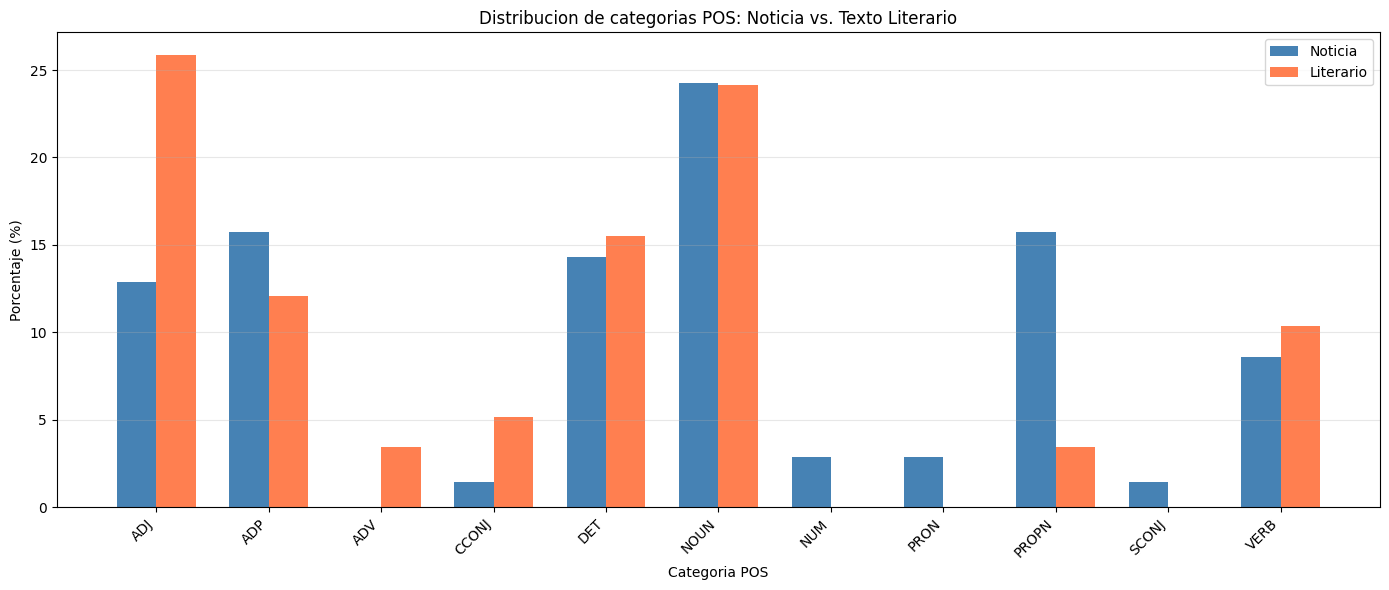


Diferencias mas notables:
--------------------------------------------------
  ADJ   : Noticia= 12.9%  Literario= 25.9%  (dif: +13.0%)
  ADV   : Noticia=  0.0%  Literario=  3.4%  (dif: +3.4%)
  NOUN  : Noticia= 24.3%  Literario= 24.1%  (dif: -0.1%)
  PROPN : Noticia= 15.7%  Literario=  3.4%  (dif: -12.3%)
  VERB  : Noticia=  8.6%  Literario= 10.3%  (dif: +1.8%)
  NUM   : Noticia=  2.9%  Literario=  0.0%  (dif: -2.9%)


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

texto_noticia = """El gobierno nacional anuncio nuevas medidas economicas para controlar
la inflacion que cerro el mes en 8,3 por ciento mensual. Segun el ministro de Economia,
Luis Caputo, se espera que estas regulaciones estabilicen el mercado cambiario.
Los analistas financieros de JP Morgan y Goldman Sachs expresaron opiniones divididas
sobre el impacto a corto plazo. La bolsa de Buenos Aires reacciono con leves caidas
tras el comunicado oficial del jueves pasado."""

texto_literario = """La tarde caia lentamente sobre la ciudad dormida, envuelta en
un silencio denso y melancolico. Viejas farolas parpadeaban debilmente, arrojando
una luz tenue y amarillenta sobre el empedrado humedo. Un gato solitario cruzo
la calle estrecha en silencio absoluto, buscando refugio del frio incipiente.
El viento susurraba secretos antiguos entre los arboles desnudos y temblorosos
del parque cercano."""

def analizar_pos_completo(texto, nombre):
    doc = nlp(texto)
    pos_tags = [token.pos_ for token in doc if token.pos_ not in ('PUNCT', 'SPACE')]
    total = len(pos_tags)
    counter = Counter(pos_tags)
    return counter, total

c_noticia, t_noticia = analizar_pos_completo(texto_noticia, "Noticia")
c_literario, t_literario = analizar_pos_completo(texto_literario, "Literario")

# Obtenemos todas las categorias POS presentes
todas_pos = sorted(set(list(c_noticia.keys()) + list(c_literario.keys())))

# Creamos el grafico de barras comparativo
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(todas_pos))
width = 0.35

pct_noticia = [c_noticia.get(pos, 0) / t_noticia * 100 for pos in todas_pos]
pct_literario = [c_literario.get(pos, 0) / t_literario * 100 for pos in todas_pos]

bars1 = ax.bar([i - width/2 for i in x], pct_noticia, width, label='Noticia', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], pct_literario, width, label='Literario', color='coral')

ax.set_xlabel('Categoria POS')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Distribucion de categorias POS: Noticia vs. Texto Literario')
ax.set_xticks(x)
ax.set_xticklabels(todas_pos, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimimos las diferencias mas notables
print("\nDiferencias mas notables:")
print("-" * 50)
for pos in ['ADJ', 'ADV', 'NOUN', 'PROPN', 'VERB', 'NUM']:
    pn = c_noticia.get(pos, 0) / t_noticia * 100
    pl = c_literario.get(pos, 0) / t_literario * 100
    diff = pl - pn
    print(f"  {pos:<6}: Noticia={pn:5.1f}%  Literario={pl:5.1f}%  (dif: {diff:+.1f}%)")

### Ejercicio 3.1: POS Tagging y analisis detallado

Dado el siguiente fragmento de un articulo cientifico:

```python
texto = """La inteligencia artificial generativa esta transformando rapidamente
la industria tecnologica a nivel mundial. Grandes empresas como Google,
Microsoft y OpenAI invierten miles de millones de dolares en investigacion
y desarrollo de nuevos modelos de lenguaje. Los modelos GPT-4 y Gemini
representan un avance significativo en la comprension y generacion de
texto en multiples idiomas. Sin embargo, expertos en etica advierten
sobre los riesgos asociados al uso indiscriminado de estas tecnologias."""
```

1. Realiza el POS tagging con spaCy y muestra los resultados en un DataFrame con columnas: Palabra, Lema, POS, DepRel, Cabeza.
2. Filtra y muestra solo los sustantivos (NOUN y PROPN) del texto. Cuantos sustantivos propios hay?
3. Filtra y muestra solo los verbos (VERB y AUX). Cuantos estan en infinitivo vs conjugados?
4. Calcula el porcentaje de cada categoria POS sobre el total de tokens (excluyendo puntuacion).
5. Identifica cual es la palabra "raiz" (root) de cada oracion y que tipo de palabra es.

### Ejercicio 3.2: NER en un comunicado de prensa

Procesa el siguiente comunicado de prensa con spaCy:

```python
comunicado = """La empresa YPF y la petrolera malaya Petronas firmaron el 15 de
marzo de 2024 un acuerdo de inversion por 2.500 millones de dolares para
la construccion de una planta de gas natural licuado en Bahia Blanca,
provincia de Buenos Aires. El presidente de YPF, Horacio Marin, y el
CEO de Petronas, Tengku Muhammad Taufik, participaron de la ceremonia
realizada en el Hotel Alvear de la Ciudad de Buenos Aires.

El proyecto, denominado Argentina LNG, generara 8.000 puestos de trabajo
directos durante la etapa de construccion prevista entre 2025 y 2028.
El gobernador de Buenos Aires, Axel Kicillof, celebro el anuncio y
destaco que Bahia Blanca se consolida como polo petroquimico nacional.
La embajadora de Malasia en Argentina, Dato Tan Yang Thai, tambien
estuvo presente en el evento."""
```

1. Extrae todas las entidades nombradas y clasificalas por tipo.
2. Agrupa las entidades por su etiqueta (PER, ORG, GPE, etc.) y muestra cuantas hay de cada tipo.
3. Visualiza las entidades con `displacy`.
4. Identifica si hay alguna entidad que spaCy clasifique incorrectamente y anota cual seria la etiqueta correcta.
5. Intenta usar GLiNER con etiquetas personalizadas como: "empresa", "persona", "monto", "ubicacion", "fecha", "proyecto". Compara los resultados con spaCy.

### Ejercicio 3.3: Comparacion de estilos de texto con POS y visualizacion

Toma los siguientes tres textos con estilos diferentes:

**Texto cientifico:**
```
"La fotosintesis es un proceso bioquimico fundamental mediante el cual los organismos
autotrofos convierten la energia luminosa del sol en energia quimica almacenada
en moleculas organicas. Este complejo proceso metabolico ocurre principalmente
en los cloroplastos de las celulas vegetales, donde la clorofila absorbe fotones
de luz visible."
```

**Texto publicitario:**
```
"Descubri el nuevo smartphone Galaxy S24 Ultra con camara de 200 megapixeles
y bateria que dura todo el dia. Compra ahora en nuestro sitio web y obtene
un descuento exclusivo del 30 por ciento. Envio gratis a todo el pais.
No te pierdas esta oferta increible por tiempo limitado."
```

**Texto legal:**
```
"El contratante se obliga a abonar al contratista la suma estipulada en la
clausula tercera del presente contrato dentro de los treinta dias corridos
posteriores a la recepcion definitiva de los trabajos. El incumplimiento
de esta obligacion generara intereses moratorios equivalentes a la tasa
activa del Banco de la Nacion Argentina."
```

1. Analiza la distribucion POS de cada texto.
2. Crea un grafico de barras comparativo (similar al ejemplo) con las categorias ADJ, NOUN, VERB, ADV, ADP para los tres textos.
3. Compara el porcentaje de adjetivos (ADJ) y verbos (VERB) entre los tres estilos.
4. Escribe un breve analisis (en comentarios) sobre que estilo tiene mayor uso de adjetivos, cual tiene mas verbos imperativos y por que tiene sentido lingueisticamente.

### Ejercicio 3.4: Extraccion de informacion estructurada con NER

Dado el siguiente texto con informacion de una transaccion comercial:

```python
texto_transaccion = """El dia 22 de noviembre de 2024, la empresa Techint S.A.C.I.
con domicilio en Av. Leandro N. Alem 1050, Ciudad Autonoma de Buenos Aires,
representada por su director general Paolo Rocca, realizo la compra de
materiales siderurgicos a la firma ArcelorMittal con sede en Luxemburgo
por un monto total de 145.000.000 de dolares estadounidenses. La operacion
fue intermediada por el Banco Santander Argentina y supervisada por
la Comision Nacional de Valores. El envio se realizara desde el puerto
de Rotterdam, Paises Bajos, hacia el puerto de San Nicolas de los Arroyos,
provincia de Buenos Aires, con fecha estimada de arribo el 15 de enero de 2025."""
```

1. Extrae las entidades con spaCy y con GLiNER (usando etiquetas: "empresa", "persona", "monto", "banco", "ubicacion", "fecha", "direccion").
2. Construi un diccionario estructurado con los datos de la transaccion: comprador, vendedor, monto, intermediario, origen, destino, fechas.
3. Muestra el resultado como un DataFrame o diccionario legible.

---

## 4. Clasificacion de texto (Text Classification)

### Fundamento teorico

La **clasificacion de texto** es una tarea de NLP que consiste en asignar una o mas categorias predefinidas a un fragmento de texto. Es una de las aplicaciones mas comunes y practicas del procesamiento del lenguaje natural.

#### Pipeline general

```
Corpus de texto -> Preprocesamiento -> Vectorizacion -> Modelo -> Evaluacion -> Inferencia
```

#### Pasos del proceso

1. **Recoleccion de datos:** obtener un conjunto de datos etiquetado con ejemplos de cada clase.
2. **Preprocesamiento:** limpiar y normalizar el texto (minusculas, eliminacion de stopwords, etc.).
3. **Vectorizacion:** transformar el texto en representaciones numericas.
4. **Entrenamiento:** entrenar un modelo de clasificacion supervisado.
5. **Evaluacion:** medir el rendimiento con metricas como precision, recall, F1-score.
6. **Inferencia:** usar el modelo entrenado para clasificar textos nuevos.

#### Metricas de evaluacion

- **Precision:** de los que el modelo predijo como clase X, cuantos realmente lo son.
- **Recall:** de todos los que realmente son clase X, cuantos el modelo identifico correctamente.
- **F1-score:** media armonica entre precision y recall.
- **Accuracy:** porcentaje total de predicciones correctas.

#### Vectorizacion: TF-IDF vs Sentence Embeddings

| Caracteristica | TF-IDF | Sentence Embeddings |
|---|---|---|
| Representacion | Vector disperso basado en frecuencias | Vector denso basado en significado semantico |
| Contexto | No captura contexto ni orden de palabras | Captura contexto, sinonimos y relaciones |
| Sinonimos | No los reconoce ("auto" != "coche") | Puede reconocer palabras semanticamente similares |
| Dimensionalidad | Alta y variable (depende del vocabulario) | Fija (ej. 384 o 768 dimensiones) |
| Velocidad | Rapido y eficiente | Requiere mas recursos (GPU recomendada) |
| Rendimiento | Bueno en tareas simples con vocabulario distintivo | Superior en tareas complejas y datos ruidosos |

### Ejemplo practico: Clasificacion con TF-IDF y Regresion Logistica

Construiremos un clasificador que distinga entre 4 categorias tematicas: desarrollo de software, videojuegos, inteligencia artificial y ciberseguridad. Este es un escenario comun en sistemas de tickets de soporte o clasificacion de consultas.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
spanish_stop_words = stopwords.words('spanish')

# Definimos las categorias
categorias = {0: "desarrollo de software", 1: "videojuegos",
              2: "inteligencia artificial", 3: "ciberseguridad"}

# Dataset de entrenamiento con frases realistas
dataset = [
    # Desarrollo de software (14 muestras)
    (0, "El equipo de backend migro la API REST de Node.js a una arquitectura de microservicios con Docker y Kubernetes."),
    (0, "Implementamos un pipeline de CI/CD con GitHub Actions para automatizar el testing y el despliegue en produccion."),
    (0, "Python es un lenguaje versatil usado en desarrollo web, ciencia de datos y automatizacion de procesos."),
    (0, "La programacion en Java sigue siendo popular en aplicaciones empresariales de gran escala."),
    (0, "El desarrollo frontend moderno utiliza frameworks como React, Vue y Angular para crear interfaces interactivas."),
    (0, "JavaScript y TypeScript son esenciales para el desarrollo web full-stack actual."),
    (0, "Los frameworks de backend como Django, Flask y FastAPI facilitan la creacion de APIs robustas."),
    (0, "Git es una herramienta esencial para el control de versiones y la colaboracion en equipos de desarrollo."),
    (0, "La documentacion y el testing automatizado son pilares fundamentales de la calidad del software."),
    (0, "Las bases de datos SQL como PostgreSQL y MySQL son fundamentales en el desarrollo de aplicaciones."),
    (0, "El patron de diseno MVC separa la logica de negocio, la presentacion y el control de flujo de la aplicacion."),
    (0, "Las metodologias agiles como Scrum y Kanban organizan el trabajo del equipo de desarrollo en sprints."),
    (0, "Los contenedores Docker permiten empaquetar aplicaciones con todas sus dependencias para un despliegue consistente."),
    (0, "Las arquitecturas serverless como AWS Lambda reducen costos al cobrar solo por el tiempo de ejecucion."),
    # Videojuegos (13 muestras)
    (1, "El nuevo juego de mundo abierto de Rockstar Games ofrece un mapa gigante con misiones secundarias y eventos dinamicos."),
    (1, "La realidad virtual esta revolucionando la experiencia de los videojuegos con cascos como el Meta Quest 3."),
    (1, "Los videojuegos indie como Hollow Knight y Celeste demostraron que no se necesita un gran presupuesto para crear obras maestras."),
    (1, "Las consolas de nueva generacion PS5 y Xbox Series X ofrecen graficos en 4K a 120 cuadros por segundo."),
    (1, "Los videojuegos de estrategia en tiempo real como Age of Empires requieren planificacion tactica y gestion de recursos."),
    (1, "Una GPU potente como la RTX 4090 es necesaria para jugar titulos AAA con ray tracing activado."),
    (1, "Los eSports generan millones de dolares en premios y atraen a audiencias de cientos de millones de espectadores."),
    (1, "Unity y Unreal Engine son los motores graficos mas utilizados para el desarrollo de videojuegos actuales."),
    (1, "Los juegos multijugador online como Fortnite y Valorant mantienen millones de jugadores activos diariamente."),
    (1, "Steam es la plataforma de distribucion digital de videojuegos mas grande del mundo con mas de 30.000 titulos."),
    (1, "El diseno de niveles es una disciplina fundamental que combina creatividad artistica con mecanicas de juego."),
    (1, "Los RPG japoneses como Final Fantasy y Persona se caracterizan por narrativas profundas y sistemas de combate por turnos."),
    (1, "Nintendo Switch logro vender mas de 130 millones de unidades combinando juego portatil y de consola."),
    # Inteligencia artificial (14 muestras)
    (2, "Los modelos de lenguaje grande como GPT-4 y Llama 3 generan texto coherente a partir de instrucciones en lenguaje natural."),
    (2, "Las redes neuronales convolucionales son la base del reconocimiento de imagenes y la vision por computadora."),
    (2, "El aprendizaje por refuerzo permitio que AlphaGo derrotara al campeon mundial de Go usando redes neuronales profundas."),
    (2, "El aprendizaje supervisado entrena modelos con datos etiquetados para hacer predicciones sobre nuevos datos."),
    (2, "Los transformers revolucionaron el procesamiento del lenguaje natural con el mecanismo de atencion multi-cabeza."),
    (2, "TensorFlow y PyTorch son los frameworks mas utilizados para entrenar redes neuronales profundas."),
    (2, "La inteligencia artificial generativa puede crear imagenes, musica y texto de forma autonoma."),
    (2, "Los modelos de difusion como DALL-E y Stable Diffusion generan imagenes a partir de descripciones textuales."),
    (2, "El fine-tuning permite adaptar un modelo pre-entrenado a una tarea especifica con pocos datos de ejemplo."),
    (2, "Las redes generativas adversarias enfrentan un generador contra un discriminador para crear contenido realista."),
    (2, "Los chatbots basados en IA como ChatGPT utilizan modelos de lenguaje para mantener conversaciones naturales."),
    (2, "La robotica combina inteligencia artificial con ingenieria mecanica para crear maquinas autonomas."),
    (2, "El aprendizaje automatico detecta patrones complejos en grandes volumenes de datos sin programacion explicita."),
    (2, "Las redes neuronales recurrentes LSTM son efectivas para procesar secuencias temporales como texto y audio."),
    # Ciberseguridad (14 muestras)
    (3, "La ciberseguridad es crucial para proteger la infraestructura critica de hospitales, centrales electricas y sistemas bancarios."),
    (3, "El ataque de ransomware WannaCry afecto a mas de 200.000 computadoras en 150 paises cifrando sus archivos."),
    (3, "Los firewalls de nueva generacion inspeccionan el trafico de red a nivel de aplicacion para detectar amenazas avanzadas."),
    (3, "La criptografia de extremo a extremo protege las comunicaciones en aplicaciones como Signal y WhatsApp."),
    (3, "La autenticacion multifactor combina contrasena, token fisico y biometria para verificar la identidad del usuario."),
    (3, "La ingenieria social explota la psicologia humana para obtener acceso no autorizado a sistemas informaticos."),
    (3, "Los ataques de phishing simulan correos legitimos de bancos o empresas para robar credenciales de acceso."),
    (3, "El malware incluye virus, troyanos, spyware y ransomware que comprometen la seguridad de los sistemas."),
    (3, "Las pruebas de penetracion simulan ataques reales para identificar vulnerabilidades antes que los atacantes."),
    (3, "El hacking etico es una profesion cada vez mas demandada con certificaciones como CEH y OSCP."),
    (3, "Los SIEM (Security Information and Event Management) correlacionan logs de multiples fuentes para detectar incidentes."),
    (3, "Las vulnerabilidades zero-day son fallos desconocidos por el fabricante que pueden ser explotados sin parche disponible."),
    (3, "La seguridad en la nube requiere configuraciones especificas en AWS, Azure y GCP para evitar filtraciones de datos."),
    (3, "Los ataques DDoS saturan los servidores con trafico masivo para dejar fuera de servicio sitios web y aplicaciones."),
]

# Preparar X e y
X = [text.lower() for label, text in dataset]
y = [label for label, text in dataset]

# Division del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total de muestras: {len(X)}")
print(f"Entrenamiento: {len(X_train)} | Test: {len(X_test)}")

# Vectorizacion con TF-IDF
vectorizer = TfidfVectorizer(stop_words=spanish_stop_words, max_features=500)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Dimensiones TF-IDF: {X_train_vec.shape}")

# Entrenamiento del modelo
modelo = LogisticRegression(max_iter=1000, solver='lbfgs')
modelo.fit(X_train_vec, y_train)

# Evaluacion
y_pred = modelo.predict(X_test_vec)
target_names = [categorias[i] for i in sorted(categorias.keys())]
report = classification_report(y_test, y_pred, target_names=target_names, zero_division=0)

print(f"\nPrecision del modelo: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nReporte de clasificacion:\n{report}")

Total de muestras: 55
Entrenamiento: 44 | Test: 11
Dimensiones TF-IDF: (44, 379)

Precision del modelo: 0.7273

Reporte de clasificacion:
                         precision    recall  f1-score   support

 desarrollo de software       1.00      0.33      0.50         3
            videojuegos       0.50      1.00      0.67         2
inteligencia artificial       1.00      1.00      1.00         3
         ciberseguridad       0.67      0.67      0.67         3

               accuracy                           0.73        11
              macro avg       0.79      0.75      0.71        11
           weighted avg       0.82      0.73      0.71        11



In [ ]:
# Inferencia: clasificar textos nuevos que el modelo nunca vio
nuevas_frases = [
    "Los domingos me gusta pasar horas jugando FIFA con mis amigos en la PlayStation.",
    "Estamos entrenando un modelo de deep learning para detectar tumores en radiografias.",
    "El equipo de DevOps configuro un cluster de Kubernetes para escalar la aplicacion automaticamente.",
    "Los hackers explotaron una vulnerabilidad SQL injection para acceder a la base de datos de clientes.",
    "La robotica industrial utiliza brazos mecanicos con vision artificial para ensamblar piezas.",
    "Steam lanza ofertas de verano con descuentos de hasta el 90 por ciento en miles de juegos.",
]

nuevas_vec = vectorizer.transform([f.lower() for f in nuevas_frases])
predicciones = modelo.predict(nuevas_vec)
probabilidades = modelo.predict_proba(nuevas_vec)

print("Clasificacion de textos nuevos:")
print("=" * 80)
for frase, pred, probs in zip(nuevas_frases, predicciones, probabilidades):
    cat = categorias[pred]
    confianza = max(probs) * 100
    print(f"  '{frase[:75]}...'")
    print(f"  -> Categoria: {cat} (confianza: {confianza:.1f}%)")
    print()

Clasificacion de textos nuevos:
  'Los domingos me gusta pasar horas jugando FIFA con mis amigos en la PlaySta...'
  -> Categoria: videojuegos (confianza: 25.7%)

  'Estamos entrenando un modelo de deep learning para detectar tumores en radi...'
  -> Categoria: ciberseguridad (confianza: 30.0%)

  'El equipo de DevOps configuro un cluster de Kubernetes para escalar la apli...'
  -> Categoria: desarrollo de software (confianza: 31.0%)

  'Los hackers explotaron una vulnerabilidad SQL injection para acceder a la b...'
  -> Categoria: inteligencia artificial (confianza: 30.0%)

  'La robotica industrial utiliza brazos mecanicos con vision artificial para ...'
  -> Categoria: inteligencia artificial (confianza: 28.8%)

  'Steam lanza ofertas de verano con descuentos de hasta el 90 por ciento en m...'
  -> Categoria: videojuegos (confianza: 32.3%)



### Ejemplo practico: Clasificacion con Sentence Embeddings

Ahora comparamos el enfoque de TF-IDF con **Sentence Embeddings**. En lugar de contar frecuencias de palabras, codificamos cada frase como un vector denso que captura su significado semantico. Esto permite que el modelo reconozca sinonimos y parafraseos.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Usamos el mismo dataset y la misma division train/test
X_textos = [text for _, text in dataset]
y_labels = [label for label, _ in dataset]
X_train_txt, X_test_txt, y_train_emb, y_test_emb = train_test_split(
    X_textos, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Codificamos con Sentence Embeddings
model_emb = SentenceTransformer('all-mpnet-base-v2')
X_train_emb = model_emb.encode(X_train_txt, show_progress_bar=True)
X_test_emb = model_emb.encode(X_test_txt, show_progress_bar=True)

print(f"Dimensiones embeddings: {X_train_emb.shape}")

# Entrenamos el mismo tipo de modelo
modelo_emb = LogisticRegression(max_iter=1000, solver='lbfgs')
modelo_emb.fit(X_train_emb, y_train_emb)

# Evaluacion
y_pred_emb = modelo_emb.predict(X_test_emb)
target_names = [categorias[i] for i in sorted(categorias.keys())]
report_emb = classification_report(y_test_emb, y_pred_emb, target_names=target_names, zero_division=0)

print(f"\nPrecision del modelo con Embeddings: {accuracy_score(y_test_emb, y_pred_emb):.4f}")
print(f"\nReporte de clasificacion:\n{report_emb}")

# Inferencia con las mismas frases nuevas
nuevas_emb = model_emb.encode(nuevas_frases)
pred_emb = modelo_emb.predict(nuevas_emb)

print("\nComparacion TF-IDF vs Embeddings en frases nuevas:")
print("=" * 80)
for frase, pred_tfidf, pred_emb_i in zip(nuevas_frases, predicciones, pred_emb):
    cat_tfidf = categorias[pred_tfidf]
    cat_emb = categorias[pred_emb_i]
    coincide = "SI" if pred_tfidf == pred_emb_i else "NO"
    print(f"  '{frase[:70]}...'")
    print(f"    TF-IDF: {cat_tfidf:<25} Embeddings: {cat_emb:<25} Coinciden: {coincide}")
    print()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Dimensiones embeddings: (44, 768)

Precision del modelo con Embeddings: 0.9091

Reporte de clasificacion:
                         precision    recall  f1-score   support

 desarrollo de software       1.00      1.00      1.00         3
            videojuegos       1.00      1.00      1.00         2
inteligencia artificial       0.75      1.00      0.86         3
         ciberseguridad       1.00      0.67      0.80         3

               accuracy                           0.91        11
              macro avg       0.94      0.92      0.91        11
           weighted avg       0.93      0.91      0.91        11


Comparacion TF-IDF vs Embeddings en frases nuevas:
  'Los domingos me gusta pasar horas jugando FIFA con mis amigos en la Pl...'
    TF-IDF: videojuegos               Embeddings: videojuegos               Coinciden: SI

  'Estamos entrenando un modelo de deep learning para detectar tumores en...'
    TF-IDF: ciberseguridad            Embeddings: inteligencia artificia

### Ejercicio 4.1: Clasificador de genero de peliculas

Construi un clasificador de texto que distinga entre 3 generos de peliculas basandose en sinopsis.

1. Crea un dataset con al menos **12 sinopsis por categoria** para los generos: **accion**, **comedia** y **terror**. Podes inventar sinopsis o inspirarte en peliculas reales, pero intenta que sean frases completas y descriptivas (no solo palabras clave).
2. Usa TF-IDF para vectorizar y Regresion Logistica para clasificar.
3. Divide en 80% entrenamiento y 20% test. Evalua el modelo con `classification_report`.
4. Clasifica las siguientes sinopsis nuevas:
   - "Un grupo de amigos se pierde en un bosque oscuro donde algo los acecha en la noche."
   - "Dos policias retirados deben volver a la accion para desmantelar una red criminal internacional."
   - "Una familia disfuncional se reune para la cena de navidad con resultados hilarantes y desastrosos."
   - "Un virus misterioso convierte a los habitantes de un pueblo en criaturas sedientas de sangre."
   - "Un agente secreto debe salvar el mundo de un villano que planea destruir satelites militares."
5. Muestra la confianza (probabilidad) de cada prediccion.

### Ejercicio 4.2: Comparacion sistematica TF-IDF vs Embeddings

Usando el mismo dataset de 4 categorias del ejemplo practico:

1. Entrena un clasificador con **TF-IDF + Regresion Logistica**.
2. Entrena otro con **Sentence Embeddings (all-mpnet-base-v2) + Regresion Logistica**.
3. Ejecuta 5 divisiones train/test diferentes (con `random_state` de 0 a 4) y calcula la precision promedio y desviacion estandar de cada enfoque.
4. Presenta los resultados en una tabla comparativa.
5. Escribe un analisis sobre cual enfoque funciono mejor y en que situaciones podria preferirse uno sobre otro.

### Ejercicio 4.3: Clasificador de intenciones de un chatbot

Construi un clasificador para detectar la **intencion** del usuario en un chatbot de servicio al cliente de una aerolinea.

Las categorias son:
- **reserva**: el usuario quiere reservar o modificar un vuelo
- **equipaje**: consultas sobre equipaje (peso, dimensiones, extra)
- **reclamo**: el usuario quiere hacer un reclamo o queja
- **informacion**: consultas generales (horarios, destinos, documentacion)

1. Crea un dataset con al menos 10 frases por categoria. Ejemplos:
   - Reserva: "Quiero reservar un vuelo a Madrid para el proximo viernes"
   - Equipaje: "Cuanto equipaje de mano puedo llevar en cabina?"
   - Reclamo: "Mi vuelo fue cancelado y nadie me dio una solucion"
   - Informacion: "Que documentos necesito para viajar a Brasil?"

2. Entrena un clasificador con TF-IDF + Regresion Logistica.
3. Evalua y prueba con consultas nuevas.
4. Bonus: muestra las 5 palabras mas importantes (con mayor coeficiente TF-IDF) para cada categoria.

---

## 5. Analisis de sentimientos (Sentiment Analysis)

### Fundamento teorico

El **analisis de sentimiento** (tambien conocido como mineria de opiniones) es un subcampo del NLP que se centra en determinar la actitud, tono u opinion expresada en un texto. Es una de las aplicaciones comerciales mas extendidas del NLP.

#### Aspectos clave

1. **Polaridad:** la orientacion emocional del texto.
   - **Positivo:** opinion favorable ("Me encanta este restaurante, la comida es exquisita").
   - **Negativo:** opinion desfavorable ("El servicio fue terrible, nunca volveria").
   - **Neutral:** sin opinion clara o texto objetivo ("El restaurante abre a las 20 horas").

2. **Intensidad:** la fuerza del sentimiento expresado. No es lo mismo "me gusta" que "me fascina absolutamente". A menudo se cuantifica en una escala (por ejemplo, de 1 a 5 estrellas).

3. **Aspecto:** analisis enfocado en diferentes atributos de un producto o servicio. Una resena puede ser positiva en un aspecto ("la pantalla es excelente") y negativa en otro ("la bateria dura muy poco").

#### Tecnicas comunes

1. **Basado en lexicones:** usa un diccionario predefinido de palabras con puntuaciones de sentimiento.
2. **Machine Learning clasico:** entrena modelos (Naive Bayes, SVM, Regresion Logistica) sobre datos etiquetados con TF-IDF.
3. **Deep Learning:** usa modelos como BERT que capturan relaciones semanticas complejas y contexto.

#### Desafios del analisis de sentimiento

- **Sarcasmo e ironia:** "Que lindo dia para quedarse encerrado" (palabras positivas, sentimiento negativo).
- **Negaciones:** "No es un mal producto" (doble negacion = positivo).
- **Contexto cultural:** expresiones coloquiales que varian por region ("esta barbaro" en Argentina = muy bueno).
- **Texto con multiples sentimientos:** "La comida deliciosa pero el servicio pesimo".
- **Emojis y lenguaje informal:** el significado cambia segun el contexto.

#### Aplicaciones comerciales

- Monitoreo de reputacion de marca en redes sociales.
- Analisis automatico de resenas de productos en e-commerce.
- Deteccion de clientes insatisfechos en centros de soporte.
- Prediccion de movimientos del mercado financiero a partir de noticias.
- Encuestas de satisfaccion del empleado.

### Ejemplo practico: Analisis con sentiment-analysis-spanish

La libreria `sentiment-analysis-spanish` proporciona un modelo pre-entrenado basado en Machine Learning (Naive Bayes con CountVectorizer) entrenado con mas de 800.000 resenas en espanol de Mercado Libre y otros sitios. Devuelve un valor entre 0 (muy negativo) y 1 (muy positivo).

In [ ]:
from sentiment_analysis_spanish import sentiment_analysis

sentiment = sentiment_analysis.SentimentAnalysisSpanish()

# Resenas reales de un restaurante (estilo Google Maps / TripAdvisor)
resenas_restaurante = [
    "Excelente lugar, la pasta casera es espectacular y los mozos muy atentos. Volveria sin dudarlo.",
    "Pesimo. Esperamos 45 minutos para que nos traigan la carta. La comida llego fria y la cuenta tenia errores.",
    "Buena relacion precio-calidad. Los platos son abundantes pero la decoracion es bastante basica.",
    "La mejor milanesa napolitana que comi en mi vida. El ambiente es acogedor y familiar.",
    "No vuelvo mas. El bano estaba sucio, la musica altisima y el mozo fue grosero.",
    "Esta bien, nada especial. La comida es correcta pero no sorprende. Precio acorde a la zona.",
    "Increible la picada para compartir. Las empanadas son caseras y el vino de la casa es muy bueno.",
    "Decepcionante. Las fotos de Instagram no tienen nada que ver con la realidad del lugar.",
]

print(f"{'Resena':<85} {'Score':>6} {'Sentimiento':>12}")
print("-" * 108)
for resena in resenas_restaurante:
    score = sentiment.sentiment(resena)
    if score > 0.6:
        tipo = "POSITIVO"
    elif score < 0.4:
        tipo = "NEGATIVO"
    else:
        tipo = "NEUTRAL"
    resena_corta = resena[:82] + "..." if len(resena) > 82 else resena
    print(f"{resena_corta:<85} {score:>6.3f} {tipo:>12}")

Resena                                                                                 Score  Sentimiento
------------------------------------------------------------------------------------------------------------
Excelente lugar, la pasta casera es espectacular y los mozos muy atentos. Volveria...  1.000     POSITIVO
Pesimo. Esperamos 45 minutos para que nos traigan la carta. La comida llego fria y...  0.000     NEGATIVO
Buena relacion precio-calidad. Los platos son abundantes pero la decoracion es bas...  0.002     NEGATIVO
La mejor milanesa napolitana que comi en mi vida. El ambiente es acogedor y famili...  0.119     NEGATIVO
No vuelvo mas. El bano estaba sucio, la musica altisima y el mozo fue grosero.         0.000     NEGATIVO
Esta bien, nada especial. La comida es correcta pero no sorprende. Precio acorde a...  0.000     NEGATIVO
Increible la picada para compartir. Las empanadas son caseras y el vino de la casa...  0.485      NEUTRAL
Decepcionante. Las fotos de Instagram no ti

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CountVectorizer from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### Ejemplo practico: Analisis con modelo BERT multilingue

Podemos usar un modelo basado en BERT (Transformers) pre-entrenado para analisis de sentimiento multilingue. El modelo `nlptown/bert-base-multilingual-uncased-sentiment` clasifica el sentimiento en una escala de 1 a 5 estrellas, lo que nos da mas granularidad que un simple positivo/negativo.

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

nlp_sentiment = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# Probamos con resenas en espanol e ingles para ver la capacidad multilingue
resenas_multilingues = [
    "La atencion al cliente fue impecable, resolvieron mi problema en minutos.",
    "Horrible experiencia, el producto vino roto y no quieren hacer el cambio.",
    "The hotel room was spacious and clean, great view of the city skyline.",
    "El envio tardo 3 semanas cuando prometieron 5 dias. Inaceptable.",
    "Muy buen producto, cumple con lo que promete. Lo recomiendo.",
    "Ni bueno ni malo, es un producto basico que cumple su funcion.",
    "Outstanding quality, the best purchase I've made this year.",
    "No funciona correctamente, ya se lo devolvi al vendedor.",
]

print(f"{'Resena':<75} {'Estrellas':>10} {'Confianza':>10}")
print("-" * 98)
for resena in resenas_multilingues:
    result = nlp_sentiment(resena)[0]
    estrellas = result['label']
    score = result['score']
    resena_corta = resena[:72] + "..." if len(resena) > 72 else resena
    print(f"{resena_corta:<75} {estrellas:>10} {score:>10.3f}")

print("\nEscala: 1 star = muy negativo, 3 stars = neutral, 5 stars = muy positivo")
print("El score indica la confianza del modelo en esa prediccion.")

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Resena                                                                       Estrellas  Confianza
--------------------------------------------------------------------------------------------------
La atencion al cliente fue impecable, resolvieron mi problema en minutos...    5 stars      0.483
Horrible experiencia, el producto vino roto y no quieren hacer el cambio...     1 star      0.953
The hotel room was spacious and clean, great view of the city skyline.         5 stars      0.520
El envio tardo 3 semanas cuando prometieron 5 dias. Inaceptable.                1 star      0.767
Muy buen producto, cumple con lo que promete. Lo recomiendo.                   5 stars      0.705
Ni bueno ni malo, es un producto basico que cumple su funcion.                 3 stars      0.428
Outstanding quality, the best purchase I've made this year.                    5 stars      0.974
No funciona correctamente, ya se lo devolvi al vendedor.                        1 star      0.756

Escala: 1 star = m

### Ejemplo practico: Analisis de sentimiento por lotes con visualizacion

En un escenario real, frecuentemente necesitamos analizar grandes cantidades de resenas y visualizar la distribucion de sentimientos. Veamos como hacerlo con un conjunto de resenas de un producto de e-commerce.

Resumen de sentimiento del producto:
  Resenas analizadas: 15
  Score promedio: 0.171
  Score mediana: 0.010

Clasificacion
Negativo    13
Positivo     2


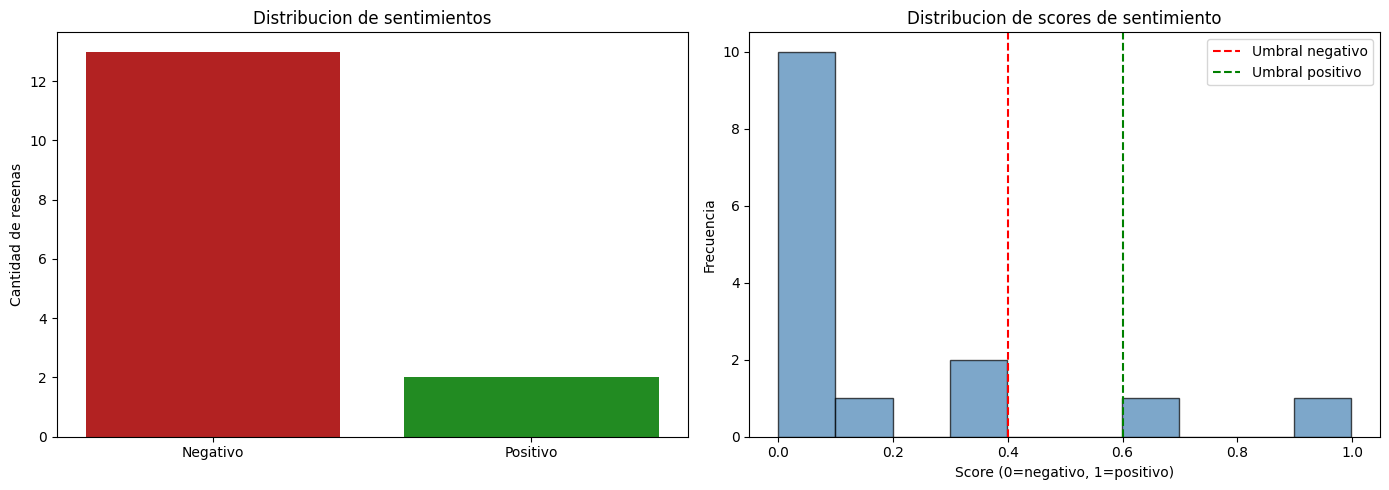

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Simulamos resenas de un producto en Mercado Libre
resenas_producto = [
    "Excelente calidad, supero mis expectativas. El material es resistente y la terminacion impecable.",
    "Muy bueno, lo uso todos los dias desde que lo compre hace 2 meses sin problemas.",
    "Llego rapido y bien empaquetado. El producto es tal cual las fotos.",
    "Buena relacion precio-calidad. No es premium pero cumple perfecto.",
    "Regular, esperaba algo mejor por el precio. El acabado tiene imperfecciones.",
    "Malo, se rompio a la semana de uso. El plastico es de muy baja calidad.",
    "No sirve, tuve que devolverlo. No coincide con la descripcion del vendedor.",
    "Pesimo servicio postventa. El producto fallo y nadie responde los mensajes.",
    "Buenisimo, lo recomiendo totalmente. Ya es la segunda unidad que compro.",
    "Increible por el precio, no encontras algo asi en otro lado.",
    "Esta bien para lo que sale. Nada del otro mundo pero funciona.",
    "Decepcionado, las fotos no representan el producto real. Muy chico.",
    "Lo mejor que compre en el ano. Mis hijos lo usan a diario y resiste todo.",
    "No lo recomiendo, la bateria dura menos de 2 horas. Publicidad enganosa.",
    "Cumple su funcion basica. El envio fue rapido, eso si.",
]

# Analizamos con sentiment-analysis-spanish
datos = []
for resena in resenas_producto:
    score = sentiment.sentiment(resena)
    if score > 0.6:
        clasificacion = "Positivo"
    elif score < 0.4:
        clasificacion = "Negativo"
    else:
        clasificacion = "Neutral"
    datos.append({'Resena': resena, 'Score': score, 'Clasificacion': clasificacion})

df_resenas = pd.DataFrame(datos)

# Estadisticas generales
print("Resumen de sentimiento del producto:")
print("=" * 50)
print(f"  Resenas analizadas: {len(df_resenas)}")
print(f"  Score promedio: {df_resenas['Score'].mean():.3f}")
print(f"  Score mediana: {df_resenas['Score'].median():.3f}")
print()
print(df_resenas['Clasificacion'].value_counts().to_string())

# Grafico de distribucion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras por clasificacion
colores = {'Positivo': 'forestgreen', 'Neutral': 'goldenrod', 'Negativo': 'firebrick'}
conteo = df_resenas['Clasificacion'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=[colores[c] for c in conteo.index])
axes[0].set_title('Distribucion de sentimientos')
axes[0].set_ylabel('Cantidad de resenas')

# Histograma de scores
axes[1].hist(df_resenas['Score'], bins=10, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].set_title('Distribucion de scores de sentimiento')
axes[1].set_xlabel('Score (0=negativo, 1=positivo)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(x=0.4, color='red', linestyle='--', label='Umbral negativo')
axes[1].axvline(x=0.6, color='green', linestyle='--', label='Umbral positivo')
axes[1].legend()

plt.tight_layout()
plt.show()

### Ejercicio 5.1: Analisis de resenas de e-commerce

Dadas las siguientes resenas de diferentes productos de un e-commerce:

```python
resenas = [
    "El producto es excelente, supero mis expectativas. La calidad de los materiales es premium.",
    "Malo, se rompio a los dos dias de uso. El plastico es fragil y la garantia no cubre nada.",
    "Esta bien para el precio que pague, nada del otro mundo pero cumple.",
    "Increible relacion calidad-precio, estoy muy satisfecho con la compra. Ya recomende a amigos.",
    "No sirve, tuve que devolverlo. El vendedor no responde y perdi tiempo y dinero.",
    "Cumple su funcion basica, ni mas ni menos. El envio fue rapido.",
    "El mejor producto que compre en anos. La bateria dura todo el dia sin problemas.",
    "Llego roto y el embalaje estaba danado. Evidente falta de cuidado en el envio.",
    "Bastante bueno en general, aunque el manual de instrucciones esta solo en chino.",
    "No lo volveria a comprar. La calidad es inferior a lo que muestran las fotos.",
    "Perfecto para regalo, llego antes de lo esperado. Mi mama quedo encantada.",
    "Funciona bien los primeros dias pero despues empieza a fallar. No es confiable a largo plazo.",
]
```

1. Analiza el sentimiento de cada resena usando `sentiment-analysis-spanish`.
2. Clasifica cada resena como POSITIVO (score > 0.6), NEUTRAL (0.4-0.6) o NEGATIVO (score < 0.4).
3. Calcula el porcentaje de resenas positivas, neutrales y negativas.
4. Calcula la puntuacion promedio de sentimiento.
5. Identifica la resena mas positiva y la mas negativa.

### Ejercicio 5.2: Comparacion de modelos de sentimiento

Usando las mismas resenas del ejercicio anterior:

1. Analiza cada resena con **ambos** modelos: `sentiment-analysis-spanish` y el modelo BERT multilingue (`nlptown/bert-base-multilingual-uncased-sentiment`).
2. Para hacer comparables los resultados de BERT (1-5 estrellas) con el score de sentiment-analysis-spanish (0-1), normaliza las estrellas BERT a un rango 0-1: `score_normalizado = (estrellas - 1) / 4`.
3. Compara los resultados en un DataFrame con las columnas: `Resena`, `Score_SA_Spanish`, `Clasificacion_SA`, `Estrellas_BERT`, `Score_BERT_norm`, `Clasificacion_BERT`.
4. Calcula la tasa de acuerdo: en que porcentaje de resenas ambos modelos coinciden en la clasificacion (positivo/neutral/negativo)?
5. Analiza: en cuales resenas difieren? Cual modelo parece mas preciso para textos en espanol?

### Ejercicio 5.3: Analisis de sentimiento por aspectos

Las siguientes resenas de un hotel mencionan multiples aspectos (ubicacion, limpieza, atencion, precio, desayuno):

```python
resenas_hotel = [
    "La ubicacion es perfecta, a dos cuadras de la playa y cerca del centro comercial. Pero la limpieza del bano dejaba mucho que desear, encontramos pelos en la banera.",
    "Personal muy amable y atento, siempre dispuestos a ayudar. El desayuno es excelente con opciones variadas. El precio es un poco elevado para la zona.",
    "La habitacion es amplia y comoda con buenas camas. La ubicacion es pesima, lejos de todo y sin transporte publico cerca. Buena relacion calidad-precio.",
    "El desayuno es pobre, solo cafe y medialunas. La atencion en recepcion fue lenta y desorganizada. Pero la pileta y el spa son increibles.",
    "Todo excelente: ubicacion centrica, habitaciones impecables, personal amabilisimo y desayuno buffet completo. Vale cada peso que pagamos.",
]
```

1. Para cada resena, separa las oraciones usando `nltk.sent_tokenize` o por puntos.
2. Analiza el sentimiento de cada oracion individual con `sentiment-analysis-spanish`.
3. Identifica a que aspecto se refiere cada oracion buscando palabras clave:
   - Ubicacion: "ubicacion", "cerca", "lejos", "zona", "cuadras"
   - Limpieza: "limpieza", "sucio", "impecable", "limpio"
   - Atencion: "personal", "atencion", "amable", "recepcion", "mozo"
   - Precio: "precio", "caro", "barato", "calidad-precio", "vale"
   - Desayuno: "desayuno", "comida", "buffet", "cafe"
4. Construi un DataFrame resumen que muestre, para cada aspecto, el sentimiento promedio y la cantidad de menciones.
5. Cual es el aspecto mejor valorado? Y el peor?

### Ejercicio 5.4: Sentimiento en titulares de noticias

Analiza el sentimiento de los siguientes titulares de noticias economicas:

```python
titulares = [
    "El dolar blue bajo 50 pesos y se acerca al valor del oficial",
    "Fuerte caida de las acciones argentinas en Wall Street tras el anuncio de nuevos impuestos",
    "La inflacion de marzo fue la mas baja en 18 meses segun el INDEC",
    "Crisis en el sector automotriz: cierran dos plantas y despiden a 3.000 trabajadores",
    "Record de exportaciones agricolas: el campo ingreso 12.000 millones de dolares",
    "El riesgo pais supero los 2.000 puntos y preocupa a los inversores internacionales",
    "Boom del turismo: los hoteles de la costa registraron ocupacion plena durante el feriado",
    "El gobierno congelo las tarifas de servicios publicos hasta fin de ano",
    "Alerta por la deuda externa: vencimientos por 15.000 millones de dolares en el proximo trimestre",
    "Crecimiento sostenido: la economia registro su quinto mes consecutivo de expansion",
]
```

1. Analiza el sentimiento de cada titular con ambos modelos.
2. Clasifica los titulares como "noticia positiva" o "noticia negativa" segun su sentimiento.
3. Calcula que porcentaje de los titulares son negativos. Es esperable en noticias economicas?
4. Hay algun titular donde el modelo se equivoque claramente? Cual y por que?

---

## 6. Busqueda semantica (Semantic Search)

### Fundamento teorico

La **busqueda semantica** consiste en encontrar documentos o pasajes que sean semanticamente relevantes para una consulta, en lugar de depender de coincidencias exactas de palabras clave. Esto resuelve una limitacion fundamental de la busqueda tradicional: las personas pueden expresar la misma idea con palabras completamente diferentes.

#### Como funciona

1. **Codificacion del corpus:** se convierten todos los textos del corpus en **embeddings** (vectores numericos densos) usando un modelo de lenguaje pre-entrenado.
2. **Codificacion de la consulta:** se convierte la consulta del usuario en un embedding con el mismo modelo.
3. **Busqueda por similitud:** se buscan los vectores del corpus mas cercanos al vector de la consulta (tipicamente usando similitud del coseno).

#### Busqueda simetrica vs asimetrica

| Tipo | Descripcion | Modelo recomendado | Ejemplo |
|---|---|---|---|
| **Simetrica** | Consulta y documentos tienen longitudes y tipos similares | `all-mpnet-base-v2`, `paraphrase-multilingual-MiniLM-L12-v2` | Buscar noticias similares a una noticia dada |
| **Asimetrica** | La consulta es corta (pregunta) y los documentos son largos (parrafos) | `msmarco-MiniLM-L-6-v3` | Preguntas de usuario contra una base de conocimiento |

#### Optimizacion para produccion

Para manejar grandes volumenes de vectores (millones de documentos), se usan librerias de busqueda aproximada de vecinos mas cercanos (ANN):

- **FAISS** (Facebook AI Similarity Search): muy eficiente en CPU y GPU.
- **Annoy** (Approximate Nearest Neighbors Oh Yeah - Spotify): bajo uso de memoria.
- **Hnswlib**: buen balance entre velocidad y precision.

### Ejemplo practico: Busqueda semantica asimetrica (preguntas y respuestas)

Usaremos un modelo pre-entrenado en MS MARCO (un corpus masivo de preguntas y respuestas reales de Bing) para construir un sistema de Q&A. El modelo esta optimizado para encontrar la mejor respuesta a una pregunta corta dentro de un corpus de textos largos.

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Cargamos un modelo entrenado para busqueda asimetrica (Q&A)
modelo_search = SentenceTransformer('msmarco-MiniLM-L-6-v3')

# Corpus de respuestas sobre temas variados (simulando una base de conocimiento)
corpus = [
    'La vida en la Tierra depende fundamentalmente de la energia solar. Esta energia es captada mediante la fotosintesis, un proceso responsable de la produccion de toda la materia organica (biomasa) que sustenta las cadenas alimenticias.',
    'Buenos Aires, la capital de Argentina, tiene una poblacion de aproximadamente 3 millones de habitantes en la ciudad autonoma y 15 millones en el area metropolitana, convirtiendola en una de las mayores urbes de America del Sur.',
    'La fotosintesis es un proceso bioquimico mediante el cual las plantas, algas y cianobacterias convierten la luz solar, dioxido de carbono y agua en glucosa y oxigeno. Ocurre en los cloroplastos y es fundamental para la vida en el planeta.',
    'El Tiranosaurio Rex fue uno de los depredadores terrestres mas grandes que jamas existio. Vivia hace entre 68 y 66 millones de anos en el Cretacico tardio, en lo que hoy es America del Norte.',
    'Los dinosaurios se extinguieron hace 66 millones de anos debido al impacto de un asteroide de aproximadamente 10 km de diametro en lo que hoy es la peninsula de Yucatan, Mexico. El evento causo un invierno global que colapso los ecosistemas.',
    'Python fue creado por Guido van Rossum y lanzado en 1991. Es un lenguaje interpretado, de alto nivel y proposito general. Su filosofia de diseno enfatiza la legibilidad del codigo con el uso de indentacion significativa.',
    'El producto bruto interno (PBI) de Argentina alcanzo los 640 mil millones de dolares en 2023, posicionandola como la tercera economia mas grande de America Latina detras de Brasil y Mexico.',
    'Las redes neuronales artificiales estan inspiradas en las neuronas biologicas del cerebro humano. Consisten en capas de nodos interconectados que procesan informacion y aprenden patrones a partir de datos de entrenamiento.',
    'La energia eolica aprovecha la fuerza del viento para generar electricidad mediante turbinas. Argentina tiene un gran potencial eolico, especialmente en la Patagonia, donde los vientos son constantes y de alta velocidad.',
    'El mate es una infusion tradicional de America del Sur, especialmente popular en Argentina, Uruguay y Paraguay. Se prepara con hojas de yerba mate y agua caliente, y se bebe con una bombilla de metal.',
]

# Consultas en lenguaje natural
consultas = [
    'Que es la fotosintesis?',
    'Cuantos habitantes tiene Buenos Aires?',
    'Por que se extinguieron los dinosaurios?',
    'Quien creo Python?',
    'Cual es el PBI de Argentina?',
    'Como funcionan las redes neuronales?',
    'Que es el mate?',
]

# Generamos los embeddings
emb_corpus = modelo_search.encode(corpus)
emb_consultas = modelo_search.encode(consultas)

# Para cada consulta, encontramos la mejor respuesta
print("SISTEMA DE BUSQUEDA SEMANTICA (Preguntas y Respuestas)")
print("=" * 80)
for i, consulta in enumerate(consultas):
    similitudes = util.cos_sim(emb_consultas[i], emb_corpus)[0]
    mejor_idx = similitudes.argmax().item()
    score = similitudes[mejor_idx].item()
    print(f"\nPregunta: {consulta}")
    print(f"Mejor respuesta (similitud: {score:.4f}):")
    print(f"  {corpus[mejor_idx][:120]}...")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SISTEMA DE BUSQUEDA SEMANTICA (Preguntas y Respuestas)

Pregunta: Que es la fotosintesis?
Mejor respuesta (similitud: 0.5790):
  La fotosintesis es un proceso bioquimico mediante el cual las plantas, algas y cianobacterias convierten la luz solar, d...

Pregunta: Cuantos habitantes tiene Buenos Aires?
Mejor respuesta (similitud: 0.5167):
  Buenos Aires, la capital de Argentina, tiene una poblacion de aproximadamente 3 millones de habitantes en la ciudad auto...

Pregunta: Por que se extinguieron los dinosaurios?
Mejor respuesta (similitud: 0.6843):
  Los dinosaurios se extinguieron hace 66 millones de anos debido al impacto de un asteroide de aproximadamente 10 km de d...

Pregunta: Quien creo Python?
Mejor respuesta (similitud: 0.4694):
  Python fue creado por Guido van Rossum y lanzado en 1991. Es un lenguaje interpretado, de alto nivel y proposito general...

Pregunta: Cual es el PBI de Argentina?
Mejor respuesta (similitud: 0.4652):
  El producto bruto interno (PBI) de Argentina al

### Ejemplo practico: Top-K respuestas con util.semantic_search

En lugar de buscar solo la mejor respuesta, podemos obtener las K mejores. Esto es util porque:
- La primera respuesta no siempre es la correcta.
- Varias respuestas pueden ser complementarias.
- Permite implementar un post-procesamiento (re-ranking) mas sofisticado.

In [ ]:
# Buscamos las top-3 respuestas para una consulta especifica
consulta = "De que depende la vida en nuestro planeta?"
emb_consulta = modelo_search.encode(consulta)

hits = util.semantic_search(emb_consulta, emb_corpus, top_k=3)

print(f"Consulta: '{consulta}'")
print("-" * 70)
for j, hit in enumerate(hits[0]):
    score = hit['score']
    texto = corpus[hit['corpus_id']]
    # Marcamos si supera el umbral minimo
    estado = "RELEVANTE" if score > 0.3 else "BAJA RELEVANCIA"
    print(f"  Resultado {j+1} [{estado}] (similitud: {score:.4f}):")
    print(f"  {texto[:120]}...")
    print()

print("Nota: Es habitual definir un umbral minimo de similitud (ej. 0.3)")
print("para descartar respuestas poco relevantes y evitar devolver ruido.")

Consulta: 'De que depende la vida en nuestro planeta?'
----------------------------------------------------------------------
  Resultado 1 [RELEVANTE] (similitud: 0.5744):
  La vida en la Tierra depende fundamentalmente de la energia solar. Esta energia es captada mediante la fotosintesis, un ...

  Resultado 2 [RELEVANTE] (similitud: 0.4447):
  La fotosintesis es un proceso bioquimico mediante el cual las plantas, algas y cianobacterias convierten la luz solar, d...

  Resultado 3 [RELEVANTE] (similitud: 0.3750):
  Los dinosaurios se extinguieron hace 66 millones de anos debido al impacto de un asteroide de aproximadamente 10 km de d...

Nota: Es habitual definir un umbral minimo de similitud (ej. 0.3)
para descartar respuestas poco relevantes y evitar devolver ruido.


### Ejemplo practico: Busqueda semantica simetrica

A diferencia de la busqueda asimetrica (pregunta corta vs. respuesta larga), la busqueda **simetrica** compara textos de longitud y tipo similar. Es util para encontrar documentos parecidos, agrupar noticias sobre el mismo tema o detectar duplicados.

In [ ]:
# Cargamos un modelo para busqueda simetrica
modelo_simetrico = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Corpus de noticias breves
noticias = [
    "El Banco Central bajo la tasa de interes de referencia al 40 por ciento anual.",
    "River Plate goleo 4-0 a Racing Club en el Monumental por la fecha 15 de la Liga Profesional.",
    "Cientificos del CONICET descubrieron una nueva especie de rana en la selva misionera.",
    "Apple presento el iPhone 16 con mejoras en la camara y un nuevo chip A18 Pro.",
    "Las inundaciones en la provincia de Buenos Aires dejaron 5.000 evacuados y cuantiosos danos.",
    "La autoridad monetaria redujo el costo del dinero para estimular el credito productivo.",
    "Boca Juniors perdio 2-1 ante Independiente en la Bombonera y se aleja del titulo.",
    "Investigadores argentinos hallaron fosiles de un dinosaurio desconocido en la Patagonia.",
    "Samsung lanzo el Galaxy S25 con inteligencia artificial integrada y pantalla plegable.",
    "Un sismo de 5.8 grados sacudio la provincia de San Juan sin causar victimas fatales.",
]

emb_noticias = modelo_simetrico.encode(noticias)

# Buscamos noticias similares a una consulta
consulta_noticia = "El equipo de futbol millonario consiguio una goleada historica en su estadio."
emb_consulta_not = modelo_simetrico.encode(consulta_noticia)

hits = util.semantic_search(emb_consulta_not, emb_noticias, top_k=3)

print(f"Consulta: '{consulta_noticia}'")
print("\nNoticias mas similares:")
print("-" * 70)
for j, hit in enumerate(hits[0]):
    print(f"  {j+1}. (similitud: {hit['score']:.4f}) {noticias[hit['corpus_id']]}")

# Construimos la matriz de similitud completa para encontrar los pares mas similares
print("\n\nMatriz de similitud entre noticias (pares mas similares):")
print("=" * 70)
sim_matrix = util.cos_sim(emb_noticias, emb_noticias)

pares = []
for i in range(len(noticias)):
    for j in range(i+1, len(noticias)):
        pares.append((i, j, sim_matrix[i][j].item()))

pares.sort(key=lambda x: x[2], reverse=True)

print("Top 5 pares de noticias mas similares:")
for i, j, sim in pares[:5]:
    print(f"  Similitud: {sim:.4f}")
    print(f"    N{i}: {noticias[i][:75]}...")
    print(f"    N{j}: {noticias[j][:75]}...")
    print()

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Consulta: 'El equipo de futbol millonario consiguio una goleada historica en su estadio.'

Noticias mas similares:
----------------------------------------------------------------------
  1. (similitud: 0.4160) River Plate goleo 4-0 a Racing Club en el Monumental por la fecha 15 de la Liga Profesional.
  2. (similitud: 0.1623) Boca Juniors perdio 2-1 ante Independiente en la Bombonera y se aleja del titulo.
  3. (similitud: 0.0995) Investigadores argentinos hallaron fosiles de un dinosaurio desconocido en la Patagonia.


Matriz de similitud entre noticias (pares mas similares):
Top 5 pares de noticias mas similares:
  Similitud: 0.5382
    N4: Las inundaciones en la provincia de Buenos Aires dejaron 5.000 evacuados y ...
    N9: Un sismo de 5.8 grados sacudio la provincia de San Juan sin causar victimas...

  Similitud: 0.4603
    N2: Cientificos del CONICET descubrieron una nueva especie de rana en la selva ...
    N7: Investigadores argentinos hallaron fosiles de un dinosaurio descon

### Ejercicio 6.1: Sistema de busqueda en documentacion tecnica

Crea un sistema de busqueda semantica sobre el siguiente corpus de documentacion tecnica:

```python
documentacion = [
    "Para instalar Python en Windows, descarga el instalador desde python.org y ejecutalo. Es importante marcar la opcion 'Add Python to PATH' durante la instalacion.",
    "Los entornos virtuales en Python aislan las dependencias de cada proyecto. Se crean con 'python -m venv nombre_entorno' y se activan con 'source nombre_entorno/bin/activate' en Linux.",
    "pip es el gestor de paquetes de Python. Para instalar un paquete: 'pip install nombre_paquete'. Para ver los instalados: 'pip list'. Para exportar: 'pip freeze > requirements.txt'.",
    "Un DataFrame de Pandas es una estructura de datos tabular bidimensional con filas y columnas etiquetadas. Se puede crear a partir de diccionarios, listas, arrays de NumPy o archivos CSV.",
    "Para leer un archivo CSV con Pandas se usa pd.read_csv('archivo.csv'). Parametros importantes: sep (separador), encoding (codificacion), usecols (columnas a cargar), dtype (tipos de datos).",
    "Git es un sistema de control de versiones distribuido creado por Linus Torvalds. Los comandos basicos son: git init, git add, git commit, git push, git pull y git merge.",
    "Para clonar un repositorio remoto se usa 'git clone URL'. Esto descarga el proyecto completo con todo su historial. Para contribuir, se crea una rama con 'git checkout -b nueva-rama'.",
    "Las listas en Python son colecciones ordenadas y mutables. Se crean con corchetes []. Operaciones comunes: append(), extend(), insert(), remove(), pop(), sort() y slicing con [inicio:fin].",
    "Los diccionarios en Python almacenan pares clave-valor. Se crean con llaves {}. Metodos utiles: keys(), values(), items(), get(), update() y pop(). Desde Python 3.7 mantienen el orden de insercion.",
    "NumPy es la libreria fundamental para computacion numerica en Python. Proporciona arrays multidimensionales (ndarray) y funciones matematicas vectorizadas que son hasta 100x mas rapidas que las listas nativas.",
    "Matplotlib es la libreria de visualizacion mas usada en Python. Para crear un grafico basico: plt.plot(x, y), plt.xlabel(), plt.ylabel(), plt.title(), plt.show(). Soporta graficos de lineas, barras, histogramas y mas.",
    "Las funciones en Python se definen con 'def nombre(parametros):'. Pueden tener valores por defecto, argumentos variables (*args, **kwargs) y anotaciones de tipo. Las funciones lambda son funciones anonimas de una linea.",
]
```

1. Codifica todo el corpus con un modelo de Sentence Transformers asimetrico.
2. Implementa una funcion `buscar(consulta, top_k=3, umbral=0.3)` que reciba una pregunta y devuelva los top-K documentos relevantes.
3. Prueba el sistema con las siguientes consultas:
   - "Como instalo una libreria en Python?"
   - "Que es un DataFrame y como se crea?"
   - "Como subo mi codigo a GitHub?"
   - "Como creo un grafico en Python?"
   - "Que son los diccionarios y como funcionan?"
4. Muestra solo los resultados que superen el umbral de similitud.

### Ejercicio 6.2: Busqueda semantica simetrica de noticias

Implementa un sistema de busqueda simetrica sobre el siguiente corpus de noticias:

```python
noticias = [
    "El gobierno anuncio un nuevo plan de ajuste economico para reducir el deficit fiscal del 5 por ciento del PBI.",
    "El equipo de futbol argentino gano la final del campeonato sudamericano con un gol en el ultimo minuto.",
    "Cientificos del CONICET descubrieron una nueva especie de insecto en la selva misionera de Argentina.",
    "La empresa de tecnologia lanzo un nuevo modelo de inteligencia artificial capaz de generar codigo automaticamente.",
    "Las inundaciones en la provincia de Entre Rios causaron la evacuacion de 3.000 familias en la costa del Parana.",
    "El banco central mantuvo la tasa de interes sin cambios pese a la presion de los mercados financieros.",
    "La seleccion argentina de basquet clasifico para los juegos olimpicos tras vencer a Brasil en la final.",
    "Investigadores de la UBA desarrollaron un nuevo tratamiento experimental contra el cancer de pulmon.",
    "La startup tecnologica argentina recibio una inversion de 50 millones de dolares de fondos de Silicon Valley.",
    "Un terremoto de magnitud 6.2 sacudio la provincia de San Juan sin dejar victimas fatales pero con danos materiales.",
    "Las exportaciones de soja alcanzaron un record historico impulsadas por la demanda de China.",
    "El club deportivo consiguio un triunfo clave que lo acerca a la clasificacion a la Copa Libertadores.",
]
```

1. Usa un modelo simetrico (`paraphrase-multilingual-MiniLM-L12-v2`).
2. Dada la consulta: `"Las autoridades presentaron medidas para estabilizar la economia del pais"`, encuentra las 3 noticias mas similares.
3. Dada la consulta: `"El equipo deportivo obtuvo una victoria importante en la competencia internacional"`, encuentra las 3 mas similares.
4. Construi la **matriz de similitud completa** (noticia x noticia) y encontra los 5 pares mas similares.
5. Visualiza la matriz de similitud como un heatmap con `seaborn` o `matplotlib`.

### Ejercicio 6.3: Pipeline de busqueda semantica con NER

Integra busqueda semantica con NER para construir un sistema que no solo encuentre textos relevantes sino que extraiga informacion estructurada de ellos.

```python
biografias = [
    "Lionel Messi nacio en Rosario, Argentina, el 24 de junio de 1987. Es considerado uno de los mejores futbolistas de todos los tiempos. Jugo en el FC Barcelona durante 21 temporadas antes de pasar al Paris Saint-Germain y luego al Inter Miami de la MLS.",
    "Marie Curie fue una fisica y quimica polaca naturalizada francesa. Gano el Premio Nobel de Fisica en 1903 y el de Quimica en 1911. Descubrio los elementos radio y polonio en su laboratorio del Instituto del Radio en Paris.",
    "Albert Einstein nacio en Ulm, Alemania, el 14 de marzo de 1879. Desarrollo la teoria de la relatividad especial y general. Gano el Premio Nobel de Fisica en 1921 por su explicacion del efecto fotoelectrico.",
    "Frida Kahlo fue una pintora mexicana nacida en Coyoacan el 6 de julio de 1907. Su obra se caracteriza por autorretratos que exploran la identidad, el cuerpo y la muerte. Fue esposa del muralista Diego Rivera.",
    "Ada Lovelace fue una matematica britanica nacida el 10 de diciembre de 1815 en Londres. Es considerada la primera programadora de la historia por su trabajo en los algoritmos para la maquina analitica de Charles Babbage.",
    "Gabriel Garcia Marquez nacio en Aracataca, Colombia, el 6 de marzo de 1927. Gano el Premio Nobel de Literatura en 1982. Su obra mas conocida es Cien anos de soledad, pilar del realismo magico latinoamericano.",
]
```

1. Implementa busqueda semantica para encontrar la biografia mas relevante para cada consulta:
   - "Quien gano dos premios Nobel?"
   - "Quien es el mejor futbolista de la historia?"
   - "Quien escribio Cien anos de soledad?"
   - "Quien fue la primera programadora?"
2. Para cada biografia encontrada, extrae las entidades nombradas con spaCy (personas, lugares, fechas, organizaciones).
3. Muestra un resumen estructurado: la respuesta textual y las entidades extraidas en formato de diccionario.

### Ejercicio 6.4: Sistema de recomendacion de articulos

Construi un sistema que, dado un articulo que el usuario esta leyendo, recomiende otros articulos similares del corpus.

```python
articulos = [
    {"titulo": "Como empezar a programar en Python desde cero", "contenido": "Python es un lenguaje ideal para principiantes por su sintaxis simple y legible. Para comenzar, instala Python desde el sitio oficial, elige un editor como VS Code y practica con ejercicios basicos de variables, condicionales y bucles."},
    {"titulo": "Las mejores recetas de pasta italiana casera", "contenido": "La pasta fresca se prepara con harina 00, huevos y sal. La clave esta en amasar durante 10 minutos y dejar reposar la masa. Las salsas clasicas como la carbonara, el pesto y la bolonesa se preparan con ingredientes frescos y simples."},
    {"titulo": "Guia de inteligencia artificial para no expertos", "contenido": "La inteligencia artificial permite a las computadoras realizar tareas que normalmente requieren inteligencia humana. Los modelos de machine learning aprenden de datos y los modelos de deep learning usan redes neuronales con multiples capas."},
    {"titulo": "Ejercicios para ganar masa muscular en el gimnasio", "contenido": "Para hipertrofia muscular se recomiendan ejercicios compuestos como sentadillas, peso muerto y press de banca. Es importante trabajar cada grupo muscular dos veces por semana con cargas progresivas y descanso adecuado."},
    {"titulo": "Aprende machine learning con Python y scikit-learn", "contenido": "Scikit-learn es la libreria mas popular para machine learning en Python. Permite implementar algoritmos de clasificacion, regresion y clustering con pocas lineas de codigo. Los pasos basicos son: cargar datos, dividir en train/test, entrenar y evaluar."},
    {"titulo": "Cocina saludable: recetas rapidas para la semana", "contenido": "Planificar las comidas de la semana ahorra tiempo y dinero. Recetas rapidas incluyen ensaladas con proteinas, bowls de arroz integral con vegetales salteados, y wraps con pollo grillado y verduras frescas."},
    {"titulo": "Entrenamiento funcional para mejorar la resistencia", "contenido": "El entrenamiento funcional mejora la fuerza, flexibilidad y resistencia cardiovascular. Incluye ejercicios como burpees, kettlebell swings, box jumps y circuitos de alta intensidad con periodos cortos de descanso."},
    {"titulo": "Desarrollo web con JavaScript y React", "contenido": "React es una libreria de JavaScript para construir interfaces de usuario interactivas. Usa componentes reutilizables, un DOM virtual para rendimiento y hooks para manejar estado y efectos secundarios en componentes funcionales."},
]
```

1. Codifica el contenido de cada articulo con un modelo simetrico.
2. Implementa una funcion `recomendar(titulo_actual, top_k=3)` que devuelva los articulos mas similares al que el usuario esta leyendo.
3. Prueba recomendando articulos para:
   - "Guia de inteligencia artificial para no expertos"
   - "Las mejores recetas de pasta italiana casera"
   - "Ejercicios para ganar masa muscular en el gimnasio"
4. Verifica que las recomendaciones sean tematicamente coherentes.

---

## Ejercicios integradores

Estos ejercicios combinan multiples tecnicas vistas a lo largo de esta practica y representan escenarios cercanos a problemas reales de NLP.

### Ejercicio integrador 1: Analizador completo de articulos periodisticos

Dado el siguiente articulo periodistico:

```python
articulo = """El presidente de Argentina, en su discurso ante la Asamblea General de
las Naciones Unidas en Nueva York, presento un ambicioso plan de reforma economica
que busca reducir la inflacion al 5 por ciento anual para el ano 2026. El ministro
de Economia, que acompano al mandatario en la comitiva oficial, declaro que las medidas
incluyen una reduccion del gasto publico de 15 mil millones de dolares y la
privatizacion de empresas estatales deficitarias.

Los analistas internacionales del Fondo Monetario Internacional expresaron cautela sobre
la viabilidad del plan. Kristalina Georgieva, directora gerente del FMI, senalo que
Argentina necesita un amplio consenso politico interno para implementar reformas
estructurales de esta magnitud. El Banco Mundial, por su parte, ofrecio asistencia
tecnica para el diseno de las politicas sociales complementarias.

En los mercados financieros, la noticia fue recibida con optimismo moderado. El riesgo
pais bajo 120 puntos basicos y la Bolsa de Buenos Aires cerro con una suba del 4.8
por ciento. Sin embargo, economistas locales como Roberto Lavagna y Marina Dal Poggetto
advirtieron que el camino sera complejo y que las metas planteadas son ambiciosas
dado el contexto regional."""
```

Realiza el siguiente analisis completo:

1. **NER:** Extrae todas las entidades nombradas y agrupalas por tipo (personas, organizaciones, lugares, cantidades).
2. **POS:** Analiza la distribucion de categorias gramaticales y muestra los 5 sustantivos y 5 verbos mas frecuentes (lematizados).
3. **Frases sustantivas:** Extrae las 10 frases sustantivas mas largas.
4. **Sentimiento:** Analiza el sentimiento general del articulo y de cada parrafo por separado. Hay diferencias entre parrafos?
5. **Resumen estructurado:** Presenta un diccionario con: tema principal, personas mencionadas, organizaciones, cifras clave, y sentimiento general.

### Ejercicio integrador 2: Sistema de FAQ inteligente para una universidad

Construi un sistema de preguntas frecuentes (FAQ) que combine clasificacion de texto y busqueda semantica.

1. Crea un corpus de FAQs con al menos 18 preguntas y respuestas distribuidas en 3 categorias:
   - **Inscripciones** (6+ preguntas): plazos, requisitos, documentacion, aranceles
   - **Becas** (6+ preguntas): tipos de becas, requisitos, plazos, montos, renovacion
   - **Academico** (6+ preguntas): correlatividades, examenes, regularidad, equivalencias

2. Implementa el siguiente pipeline:
   a. Cuando el usuario hace una consulta, **clasifica** la consulta en una de las 3 categorias (usando TF-IDF + LogReg).
   b. Dentro de esa categoria, usa **busqueda semantica** para encontrar la pregunta mas similar del corpus.
   c. Devuelve la respuesta correspondiente.

3. Prueba el sistema con al menos 6 consultas formuladas de forma diferente a las del corpus, por ejemplo:
   - "Cuando tengo que anotarme para el cuatrimestre?"
   - "Hay alguna ayuda economica para estudiantes?"
   - "Cuantas materias puedo deber para mantener la regularidad?"

4. Muestra: la categoria predicha, la pregunta mas similar encontrada, y la respuesta.

### Ejercicio integrador 3: Analisis de opiniones de un producto con multiples tecnicas

Dado el siguiente conjunto de opiniones sobre un servicio de streaming (tipo Netflix/Spotify):

```python
opiniones = [
    "El catalogo es enorme, siempre encuentro algo nuevo para ver. La calidad de imagen en 4K es impresionante.",
    "Demasiado caro para lo que ofrece. Suben el precio cada 3 meses y eliminan contenido bueno.",
    "La app se cuelga constantemente en mi Smart TV Samsung. El soporte tecnico no resuelve nada.",
    "Las series originales son excelentes, especialmente los documentales de naturaleza y ciencia.",
    "Cancelaron mi serie favorita despues de una sola temporada. Estoy furioso.",
    "Buena plataforma en general. La interfaz es intuitiva y las recomendaciones son acertadas.",
    "No vale la pena. El contenido en espanol es muy limitado y los subtitulos tienen errores.",
    "La funcion de perfiles familiares es genial. Cada miembro tiene sus propias recomendaciones.",
    "Baje la calidad del plan basico y ahora tiene publicidad. Inaceptable por el precio que cobran.",
    "El mejor servicio de streaming del mercado. Lo uso todos los dias sin quejas.",
]
```

Realiza el siguiente analisis completo:

1. **Sentimiento:** Analiza cada opinion con ambos modelos (sentiment-analysis-spanish y BERT) y compara.
2. **Clasificacion tematica:** Clasifica cada opinion en una de estas categorias: "contenido", "precio", "tecnico", "interfaz" (puedes usar palabras clave o un clasificador simple).
3. **Frases sustantivas:** Extrae las frases sustantivas de las opiniones negativas para identificar los principales puntos de dolor.
4. **Busqueda semantica:** Implementa un buscador que, dado un tema de interes (ej. "problemas tecnicos"), encuentre las opiniones mas relevantes.
5. **Resumen ejecutivo:** Genera un resumen con: sentimiento promedio, distribucion por categoria, principales elogios y principales quejas.

---

**Fin de la practica.** Esta practica cubrio las tecnicas fundamentales de procesamiento del lenguaje natural de la Unidad 3: extraccion de frases sustantivas, semejanza de texto con multiples metricas, POS tagging y NER (con spaCy, Stanza y GLiNER), clasificacion de texto (TF-IDF y Sentence Embeddings), analisis de sentimientos (modelos clasicos y BERT) y busqueda semantica (simetrica y asimetrica). Estas herramientas forman la base sobre la cual se construyen aplicaciones avanzadas de NLP en la industria.